#About Yulu


---




>Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

>Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

>Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

```

##Business Problem


---



The company wants to know:

>Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
How well those variables describe the electric cycle demands

#Import Libraries


---



In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import textwrap
import statsmodels.api as sm

from scipy import stats
from scipy.stats import ttest_ind, levene, shapiro, f_oneway, kruskal, chi2_contingency, pearsonr
from statsmodels.graphics.gofplots import qqplot
from statsmodels.formula.api import ols

#Load Dataset

Dataset: yulu_data.csv


Column Profiling:

      - datetime: datetime
      - season: season (1: spring, 2: summer, 3: fall, 4: winter)
      - holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
      - workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
      - weather:
        1. Clear, Few clouds, partly cloudy, partly cloudy
        2. Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
        3. Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
        4. Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
      - temp: temperature in Celsius
      - atemp: feeling temperature in Celsius
      - humidity: humidity
      - windspeed: wind speed
      - casual: count of casual users
      - registered: count of registered users
      - count: count of total rental bikes including both casual and registered

In [28]:
df=pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv')

df_backup=df.copy(deep=True)

np.shares_memory(df,df_backup)

False

#Utility Functions

##Univariate Plot Function

In [29]:

def bar_plots(df, cat_cols, top_n=None, show_percent=True, color="royalblue", wrap_len=15):
    """
    Vertical count bar plots for categorical columns with adaptive layout:
    - Columns with <10 unique categories: 2 per row
    - Columns with >=10 unique categories: 1 per row
    - Bars sorted descending
    - Counts + percentage displayed above bars
    - Solid deep color
    - Correct label alignment
    - Handles top_n categories and groups rest as 'Other'
    - Wraps long category names automatically
    """

    # Split columns based on unique categories
    few_cat_cols = [col for col in cat_cols if df[col].nunique() < 10]
    many_cat_cols = [col for col in cat_cols if df[col].nunique() >= 10]

    # -------------------
    # Few categories (<10)
    # -------------------
    if few_cat_cols:
        n_cols = 2
        n_rows = int(np.ceil(len(few_cat_cols)/n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
        axes = axes.flatten()

        for i, col in enumerate(few_cat_cols):
            counts = df[col].value_counts().sort_values(ascending=False)
            plot_data = counts.reset_index()
            plot_data.columns = [col, "count"]
            total = plot_data["count"].sum()

            ax = axes[i]
            sns.barplot(
                x=col,
                y="count",
                data=plot_data,
                ax=ax,
                color=color,
                order=plot_data[col].tolist()
            )

            ax.set_title(f"{col} Distribution", fontsize=14, fontweight="bold", pad=15)
            ax.set_ylabel("Count", fontsize=12)
            ax.set_xlabel(col, fontsize=12)

            # Wrap long labels
            labels = [ "\n".join(textwrap.wrap(str(l), wrap_len)) for l in plot_data[col].astype(str)]
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, ha="right", fontsize=10)

            y_max = plot_data["count"].max()
            ax.set_ylim(0, y_max * 1.2)

            # Annotate
            for p, count_val in zip(ax.patches, plot_data["count"]):
                label = f"{count_val}\n({count_val/total*100:.1f}%)" if show_percent else f"{count_val}"
                ax.annotate(
                    label,
                    (p.get_x() + p.get_width() / 2., p.get_height() + y_max*0.02),
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color="black"
                )

        # Remove empty axes
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # -------------------
    # Many categories (>=10)
    # -------------------
    for col in many_cat_cols:
        counts = df[col].value_counts()

        # Handle top_n
        if top_n is not None and top_n < len(counts):
            top_counts = counts.nlargest(top_n)
            other_count = counts.sum() - top_counts.sum()
            plot_data = top_counts.append(pd.Series({"Other": other_count}))
            plot_data = plot_data.sort_values(ascending=False)
        else:
            plot_data = counts.sort_values(ascending=False)

        plot_data = plot_data.reset_index()
        plot_data.columns = [col, "count"]
        total = plot_data["count"].sum()

        plt.figure(figsize=(16,6))
        ax = sns.barplot(
            x=col,
            y="count",
            data=plot_data,
            color=color,
            order=plot_data[col].tolist()
        )
        ax.set_title(f"{col} Distribution", fontsize=14, fontweight="bold", pad=15)
        ax.set_ylabel("Count", fontsize=12)
        ax.set_xlabel(col, fontsize=12)

        # Wrap long labels
        labels = [ "\n".join(textwrap.wrap(str(l), wrap_len)) for l in plot_data[col].astype(str)]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, ha="right", fontsize=10)

        y_max = plot_data["count"].max()
        ax.set_ylim(0, y_max * 1.2)

        # Annotate
        for p, count_val in zip(ax.patches, plot_data["count"]):
            label = f"{count_val}\n({count_val/total*100:.1f}%)" if show_percent else f"{count_val}"
            ax.annotate(
                label,
                (p.get_x() + p.get_width() / 2., p.get_height() + y_max*0.02),
                ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="black"
            )

        plt.tight_layout()
        plt.show()


In [30]:

def numerical_columns_distribution_with_stats(df):
    cols=df.select_dtypes(exclude=['category', 'datetime']).columns
    for col in cols:

      data = df[col].dropna()

      # Calculate statistics
      mean_val = data.mean()
      median_val = data.median()
      std_val = data.std()
      min_val = data.min()
      max_val = data.max()

      # Print statistics
      print(f"Statistics for {col}:")
      print(f"  Mean   : {mean_val:.2f}")
      print(f"  Median : {median_val:.2f}")
      print(f"  Std Dev: {std_val:.2f}")
      print(f"  Min    : {min_val:.2f}")
      print(f"  Max    : {max_val:.2f}")

      plt.figure(figsize=(15, 5))

      # Histogram
      plt.subplot(1, 3, 1)
      #plt.hist(data, bins=30, color='skyblue', edgecolor='black')
      sns.histplot(
        data=df,             # your DataFrame
        x=data,        # column to plot
        bins=30,             # number of bins
        kde=True,            # add kernel density estimate
        color='royalblue',   # bar color
        edgecolor='black',   # edge of bars
        stat='density'       # normalize histogram to density (optional)
        )
      plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.0f}")
      plt.axvline(median_val, color='green', linestyle='--', label=f"Median: {median_val:.0f}")
      plt.title(f"Histogram of {col}")
      plt.xlabel(f"{col} Amount")
      plt.ylabel("Frequency")
      plt.legend()

      # Boxplot
      plt.subplot(1, 3, 2)
      sns.boxplot(x=data, color='orange')
      plt.title(f"Boxplot of {col}")
      plt.xlabel(f"{col} Amount")
      plt.text(mean_val, 0.02, f"Mean: {mean_val:.0f}", ha='center', color='red')
      plt.text(median_val, -0.05, f"Median: {median_val:.0f}", ha='center', color='green')

      # Density plot
      plt.subplot(1, 3, 3)
      sns.kdeplot(data, fill=True, color='green')
      plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.0f}")
      plt.axvline(median_val, color='blue', linestyle='--', label=f"Median: {median_val:.0f}")
      plt.title(f"Density Plot of {col}")
      plt.xlabel(f"{col} Amount")
      plt.legend()

      plt.tight_layout()
      plt.show()


##Bivariate Plot Function

In [31]:


def plot_cat(df, cat_cols, target='count', wrap_len=15):
    """
    Creates bar and box plots (2 plots per row) for given categorical columns vs target.
    - Deep royal blue for bar plots
    - Deep orange for box plots
    - Automatically wraps long category names
    """
    sns.set_theme(style="whitegrid", font_scale=1.1)

    bar_color = 'royalblue'    # Deep Royal Blue
    box_color = '#FF7F11'    # Deep Orange

    n = len(cat_cols)
    rows = math.ceil(n)
    fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # --- Bar Plot (Mean Rentals) ---
        ax = axes[2*i]
        sns.barplot(ax=ax, data=df, x=col, y=target, estimator='mean', errorbar=None, color=bar_color)
        ax.set_title(f'Average {target.capitalize()} by {col.capitalize()}')
        ax.set_xlabel(col.capitalize())
        ax.set_ylabel(f'Average {target.capitalize()}')

        # Wrap long labels
        labels = [ "\n".join(textwrap.wrap(str(l), wrap_len)) for l in df[col].astype(str).unique() ]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, ha='right', fontsize=10)

        # --- Box Plot (Distribution) ---
        ax2 = axes[2*i + 1]
        sns.boxplot(ax=ax2, data=df, x=col, y=target, color=box_color)
        ax2.set_title(f'{target.capitalize()} Distribution by {col.capitalize()}')
        ax2.set_xlabel(col.capitalize())
        ax2.set_ylabel(target.capitalize())

        labels2 = [ "\n".join(textwrap.wrap(str(l), wrap_len)) for l in df[col].astype(str).unique() ]
        ax2.set_xticks(range(len(labels2)))
        ax2.set_xticklabels(labels2, ha='right', fontsize=10)

    # Remove unused subplots if odd number of categorical columns
    for j in range(2 * n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [32]:


def plot_time_trends(df, time_cols, target='count', line_color='#1E3A8A'):
    """
    Creates line plots for time-specific columns vs target.
    - Deep royal blue line with markers
    - Aggregates mean target for each time value

    Parameters:
        df (pd.DataFrame): Your dataframe
        time_cols (list): List of numeric/ordered time columns (hour, day, month, year)
        target (str): Target variable (default='count')
        line_color (str): Color for the line (default deep royal blue)
    """


    n = len(time_cols)
    rows = math.ceil(n / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(14, 5*rows))
    axes = axes.flatten()

    for i, col in enumerate(time_cols):
        ax = axes[i]
        agg_df = df.groupby(col, observed=True)[target].mean().reset_index()

        ax.plot(agg_df[col], agg_df[target], marker='o', color=line_color, linewidth=2)
        ax.set_title(f'Average {target.capitalize()} by {col.capitalize()}')
        ax.set_xlabel(col.capitalize())
        ax.set_ylabel(f'Average {target.capitalize()}')
        ax.set_xticks(agg_df[col])
        ax.set_xticklabels(agg_df[col], rotation=45, ha='right', fontsize=10)

    # Remove unused subplots if number of columns is odd
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [33]:

def plot_kde(data_list, data_dict):
    """
    Plots KDEs for a list of datasets.
    Skips datasets with <=1 element and shows a message instead.
    data_dict: dictionary mapping dataset index to description.
    """
    cols = 2
    rows = int(np.ceil(len(data_list) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for i, data in enumerate(data_list):
        ax = axes[i]
        name = f"Dataset {i+1}"
        desc = data_dict.get(i+1, "")

        if len(data) > 1:
            sns.kdeplot(data, fill=True, ax=ax)
            ax.set_title(f"{name}\n{desc}", fontsize=10)
        else:
            ax.text(0.5, 0.5, f"{name}\nNot enough data\n(n={len(data)})",
                    ha='center', va='center', fontsize=11, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)
            ax.set_title(desc, fontsize=9, color='gray')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_qq(data_list, data_dict):
    """
    Plots Q-Q plots for a list of datasets.
    Skips datasets with <=1 element and shows a message instead.
    data_dict: dictionary mapping dataset index to description.
    """
    cols = 2
    rows = int(np.ceil(len(data_list) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for i, data in enumerate(data_list):
        ax = axes[i]
        name = f"Dataset {i+1}"
        desc = data_dict.get(i+1, "")

        if len(data) > 1:
            stats.probplot(data, dist="norm", plot=ax)
            ax.set_title(f"{name}\n{desc}", fontsize=10)
        else:
            ax.text(0.5, 0.5, f"{name}\nNot enough data\n(n={len(data)})",
                    ha='center', va='center', fontsize=11, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)
            ax.set_title(desc, fontsize=9, color='gray')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


##Outlier Detection Functions

In [35]:
def detect_outliers_iqr(df):
    outlier_info = {}
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_info[col] = {
            "outlier_count": outliers.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "min_value": df[col].min(),
            "max_value": df[col].max(),
            "possible_errors": df[(df[col] < 0) & (df[col].dtype in ['int64','float64'])][col].tolist()
        }
    return outlier_info




In [36]:

def iqr_outliers_boxplot(df):
    """
    Detects outliers in numeric columns using the IQR method

    """
    sns.set_palette("deep")  # Deep solid color theme
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]

        print(f"\nColumn: {col}")
        print(f"Number of outliers (IQR method): {len(outliers)}")

        # Boxplot
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col], color='royalblue')
        plt.title(f'Boxplot of {col}')
        plt.show()


##Hypothesis Testing functions

In [37]:
def check(p,alpha):
  print('p = ',p)
  print('alpha = ',alpha,'\n')
  if p<=alpha:
    print('p <= alpha\n')
    print("Ho - reject\nHa - accept")
  else:
    print('p > alpha\n')
    print("Fail to reject Ho\n")

#Basic Analysis

##Non-Graphical Analysis

In [38]:
df.shape

(10886, 12)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [40]:
sum(df.duplicated())

0

In [41]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [42]:
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


In [43]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [44]:
df['datetime']=df["datetime"].astype('datetime64[ns]')
df['year']=df['datetime'].dt.year
df['month']=df['datetime'].dt.month
df['date']=df['datetime'].dt.day
df['hour']=df['datetime'].dt.hour

df['month_name']=df['datetime'].dt.month_name()
df['day_name']=df['datetime'].dt.day_name()

df[['year', 'month', 'date', 'day_name', 'month_name', 'hour']]

,year,month,date,day_name,month_name,hour
0,2011,1,1,Saturday,January,0
1,2011,1,1,Saturday,January,1
2,2011,1,1,Saturday,January,2
3,2011,1,1,Saturday,January,3
4,2011,1,1,Saturday,January,4
...,...,...,...,...,...,...
10881,2012,12,19,Wednesday,December,19
10882,2012,12,19,Wednesday,December,20
10883,2012,12,19,Wednesday,December,21
10884,2012,12,19,Wednesday,December,22


In [45]:
season = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
holiday = {0: "no", 1: "yes"}
workingday = {0: "no", 1: "yes"}
weather = { 1: "Clear, Few clouds, partly cloudy, partly cloudy",
            2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist",
            3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds",
            4: "Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog"
          }

df['season']=df['season'].map(season)
df['holiday']=df['holiday'].map(holiday)
df['workingday']=df['workingday'].map(workingday)
df['weather']=df['weather'].map(weather)

In [46]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'date', 'hour', 'month_name', 'day_name'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  object        
 3   workingday  10886 non-null  object        
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  date        10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  month_name  10886 non-

In [48]:
for i in df.columns[1:5]:
  df[i]=df[i].astype('category')

for i in df.columns[12:]:
  df[i]=df[i].astype('category')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  category      
 13  month       10886 non-null  category      
 14  date        10886 non-null  category      
 15  hour        10886 non-null  category      
 16  month_name  10886 non-

In [49]:
for i in df.columns[1:]:
  print('='*20)
  print(i)
  print('='*20)
  print(df[i].value_counts())
  print('\n')
  print('-'*20)
  print('-'*20)
  print('\n')

season
season
winter    2734
fall      2733
summer    2733
spring    2686
Name: count, dtype: int64


--------------------
--------------------


holiday
holiday
no     10575
yes      311
Name: count, dtype: int64


--------------------
--------------------


workingday
workingday
yes    7412
no     3474
Name: count, dtype: int64


--------------------
--------------------


weather
weather
Clear, Few clouds, partly cloudy, partly cloudy                                            7192
Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist                               2834
Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds     859
Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog                                    1
Name: count, dtype: int64


--------------------
--------------------


temp
temp
14.76    467
26.24    453
28.70    427
13.94    413
18.86    406
22.14    403
25.42    403
16.40    400
22.96    395
27.06    394
24.60    3

In [50]:
for i in df.columns[1:]:
  print('='*20)
  print(i)
  print('='*20)
  print(df[i].value_counts(normalize=True)*100)
  print('\n')
  print('-'*20)
  print('-'*20)
  print('\n')

season
season
winter    25.114826
fall      25.105640
summer    25.105640
spring    24.673893
Name: proportion, dtype: float64


--------------------
--------------------


holiday
holiday
no     97.14312
yes     2.85688
Name: proportion, dtype: float64


--------------------
--------------------


workingday
workingday
yes    68.087452
no     31.912548
Name: proportion, dtype: float64


--------------------
--------------------


weather
weather
Clear, Few clouds, partly cloudy, partly cloudy                                            66.066507
Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist                               26.033437
Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds     7.890869
Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog                                  0.009186
Name: proportion, dtype: float64


--------------------
--------------------


temp
temp
14.76    4.289914
26.24    4.161308
28.70    3.922469
13

In [51]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


In [52]:
cat_cols=df.select_dtypes(include='category').columns
cat_cols

Index(['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'date',
       'hour', 'month_name', 'day_name'],
      dtype='object')

In [53]:
num_cols=df.select_dtypes(exclude=['category', 'datetime']).columns
num_cols

Index(['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered',
       'count'],
      dtype='object')

##Visual Analysis - Univariate & Bivariate

###Univariate Analysis

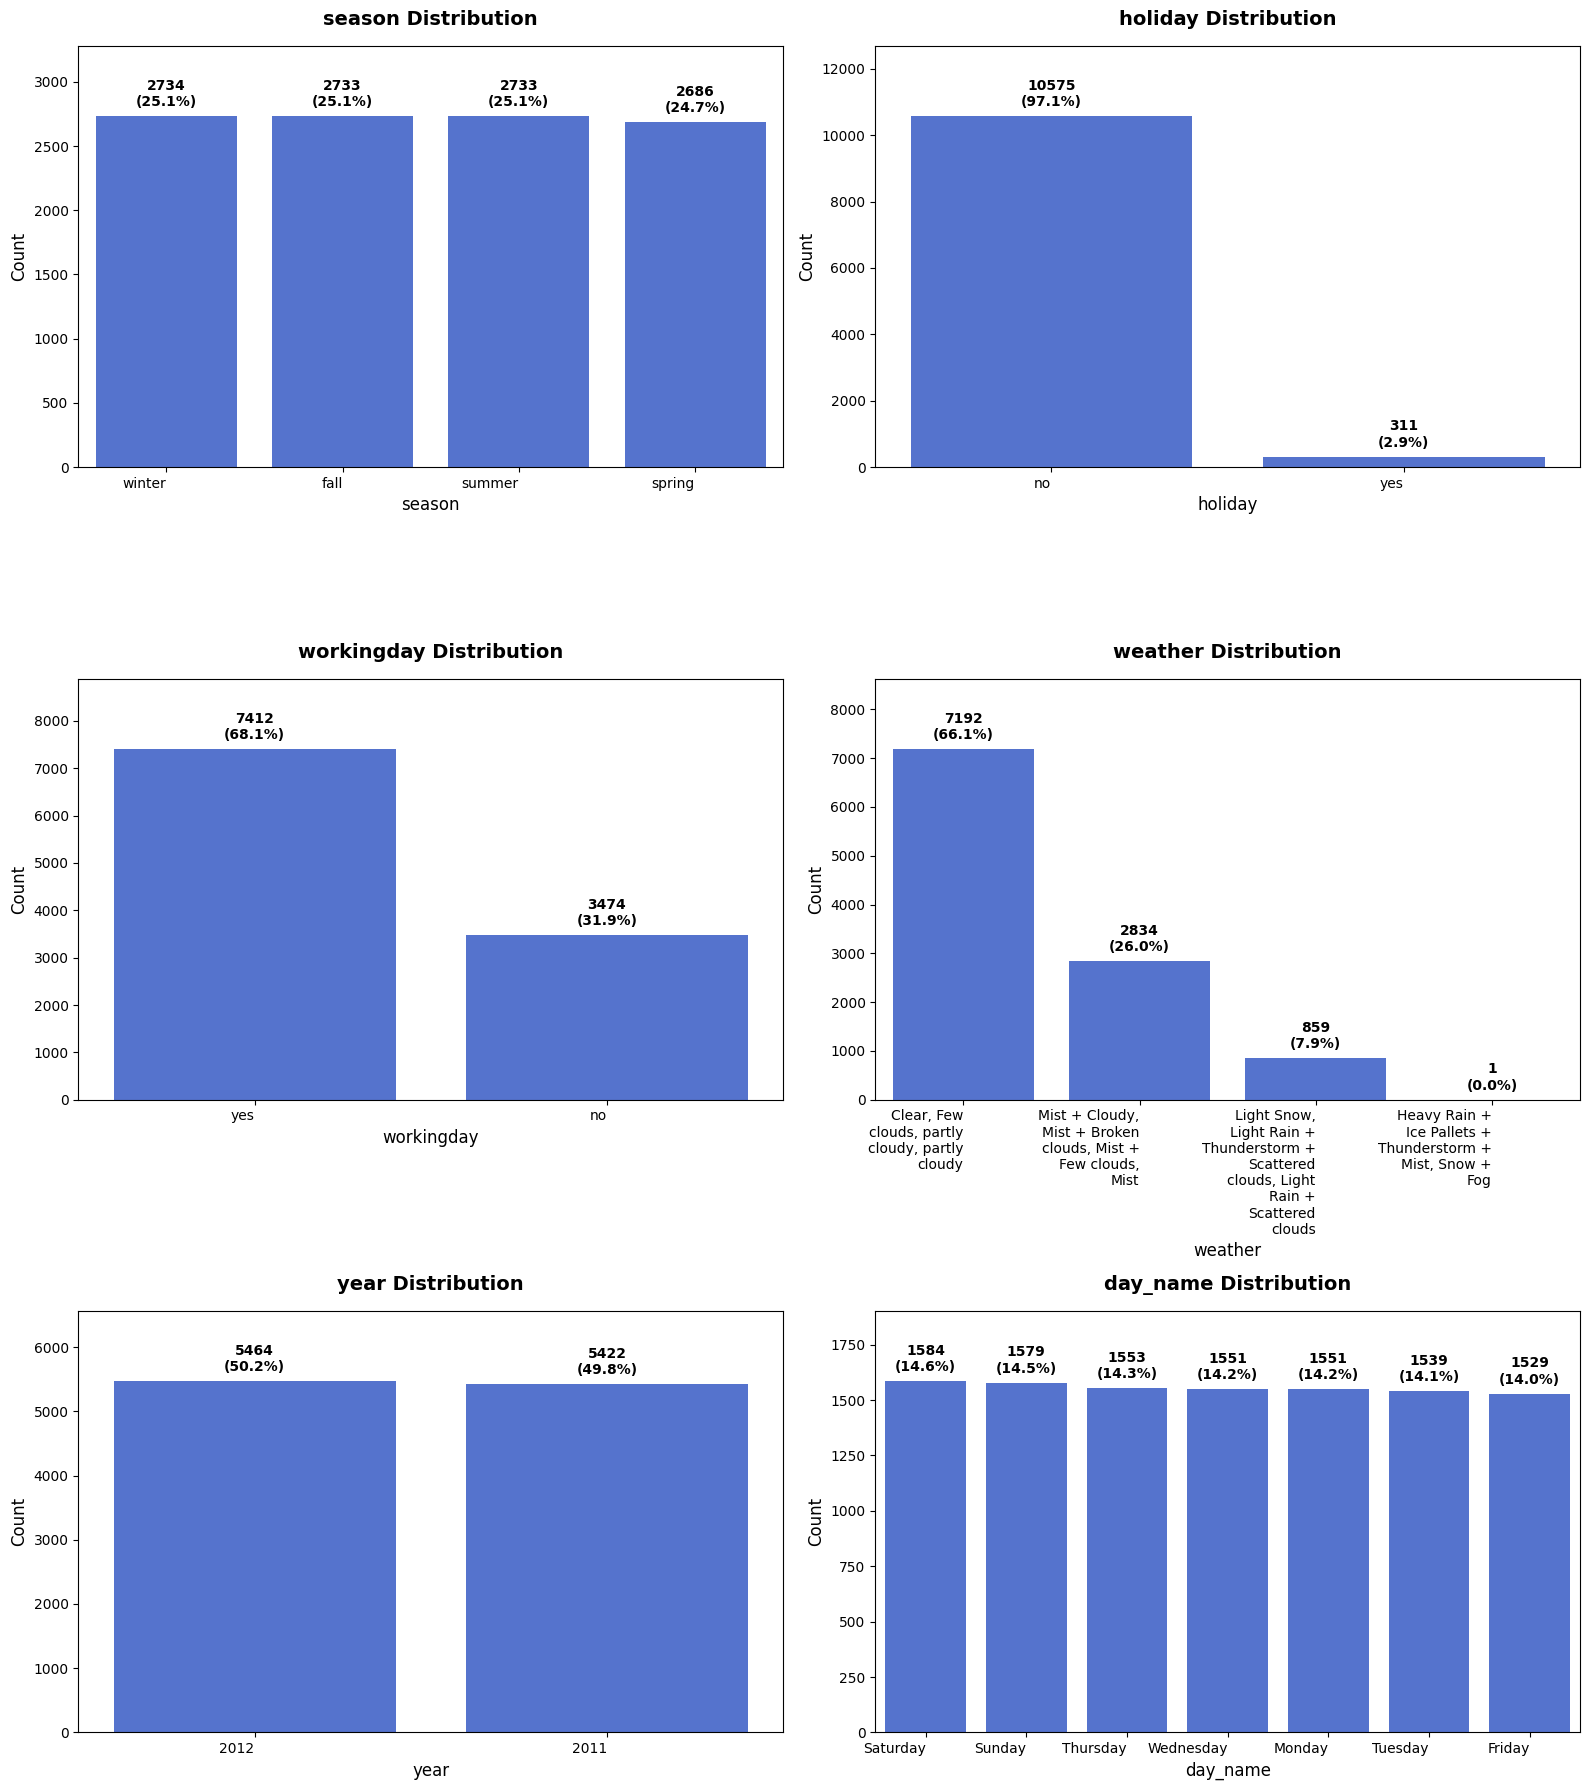

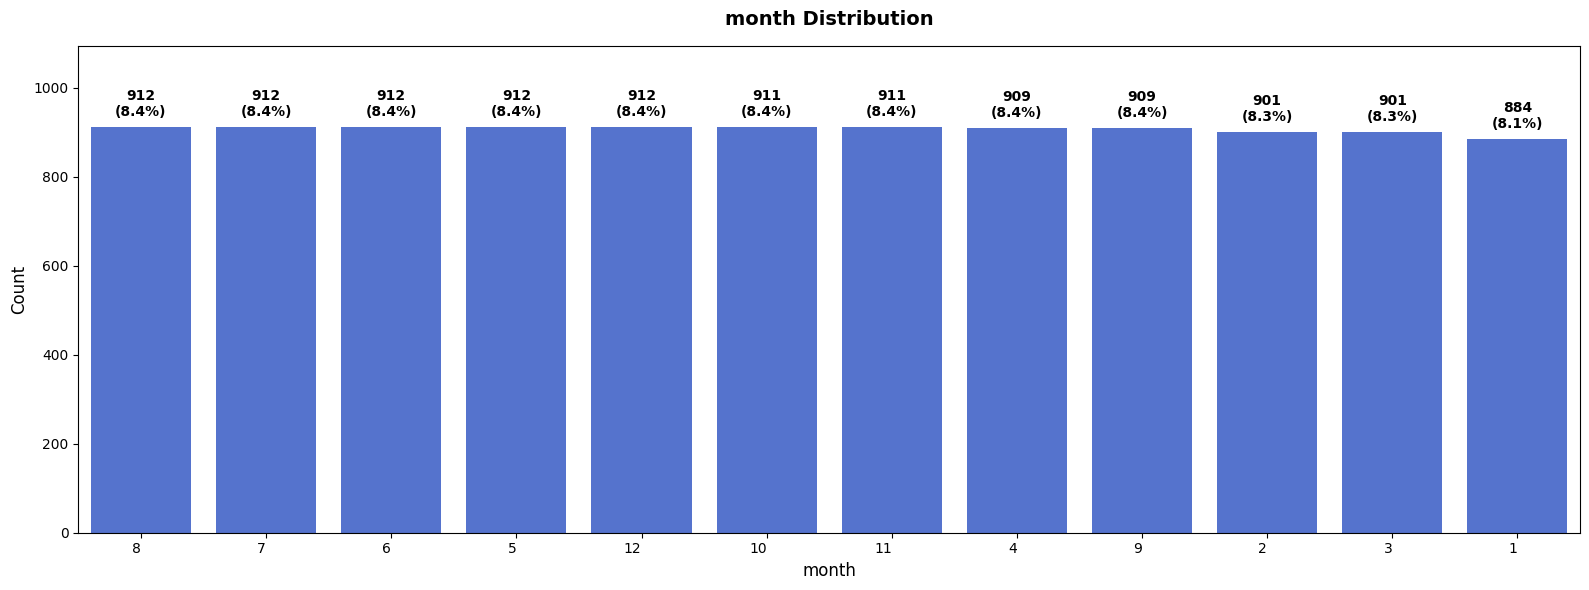

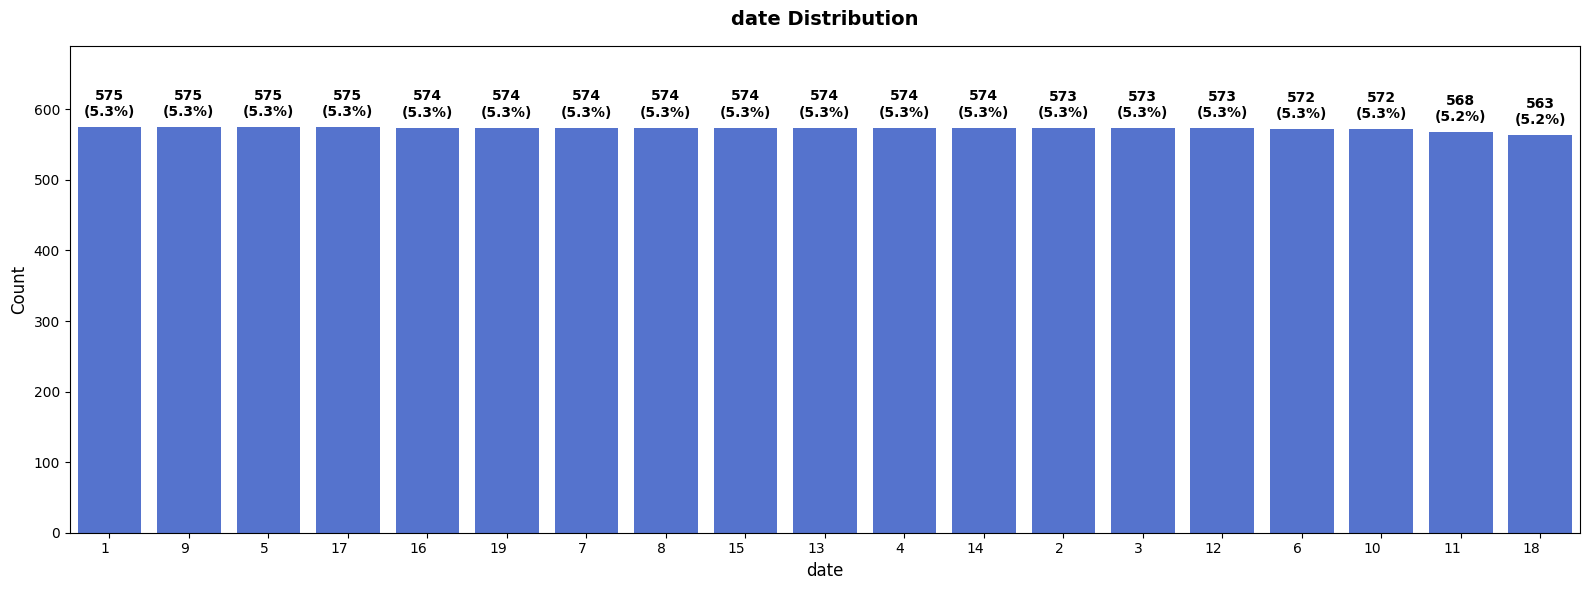

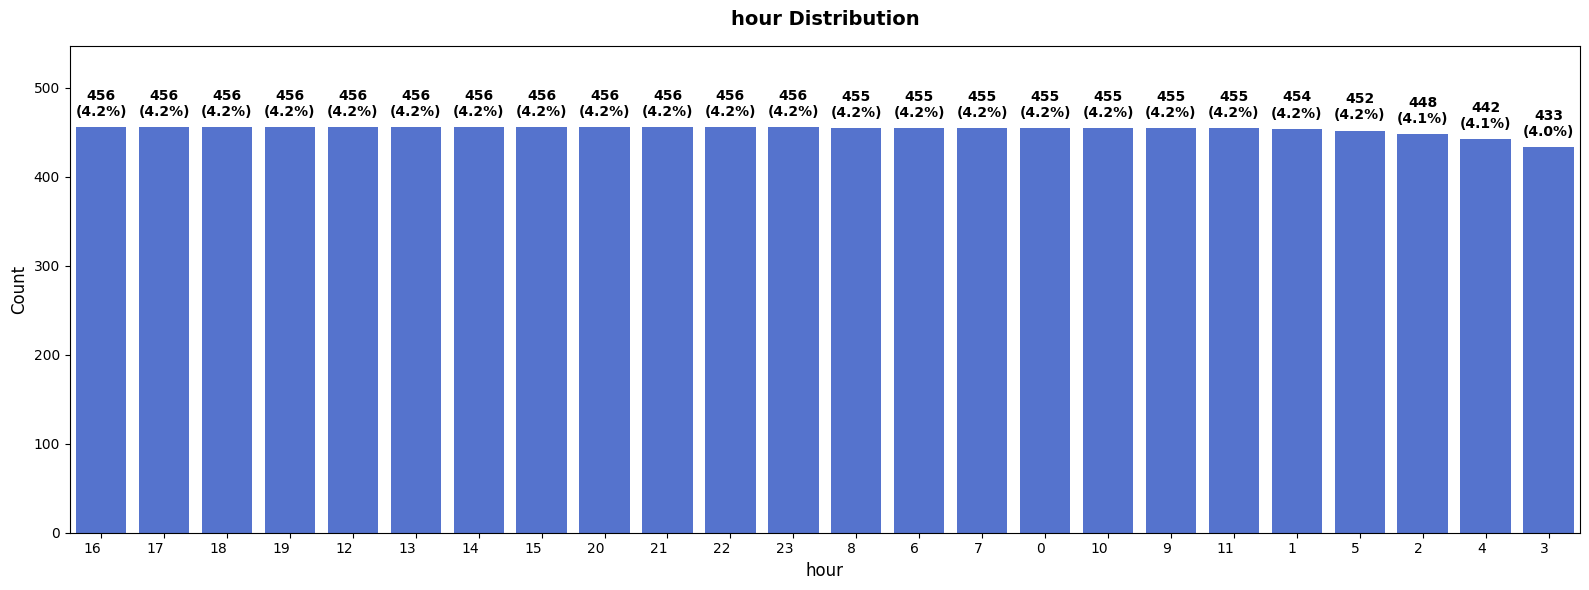

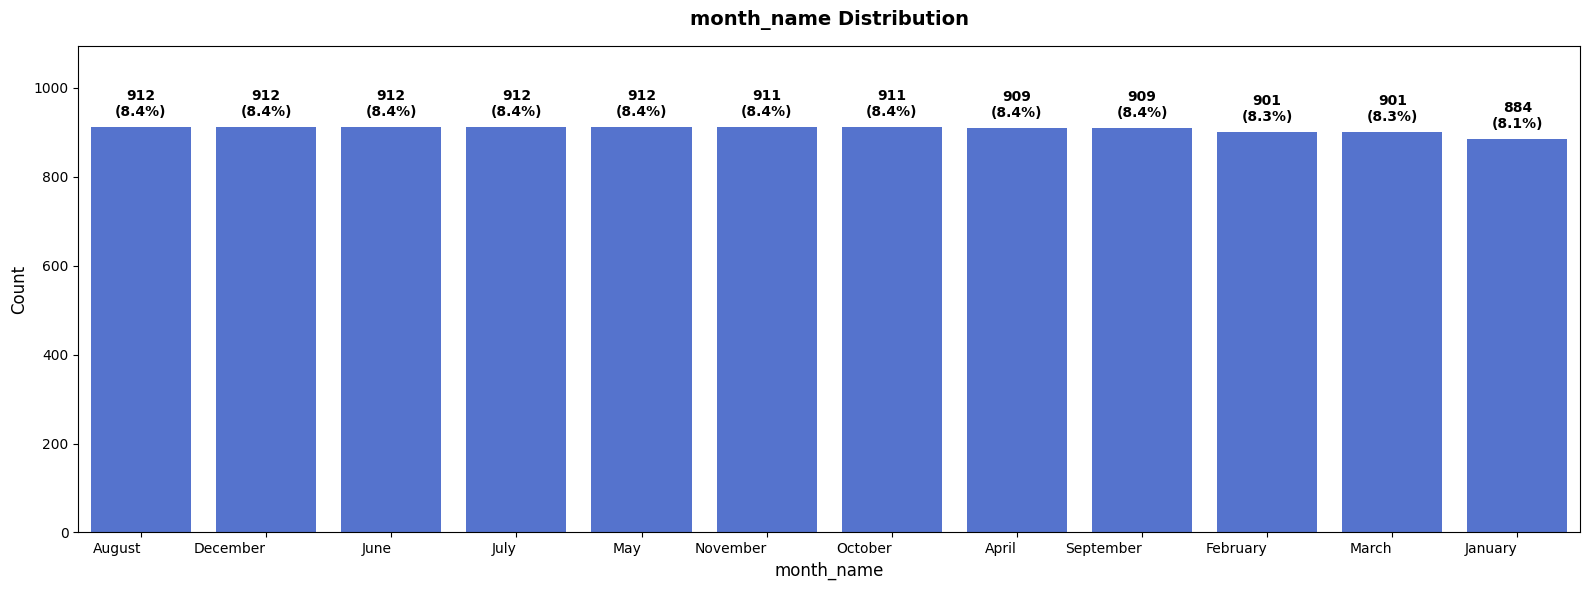

In [54]:
bar_plots(df, cat_cols, top_n=None, show_percent=True, color="royalblue")

Statistics for temp:
  Mean   : 20.23
  Median : 20.50
  Std Dev: 7.79
  Min    : 0.82
  Max    : 41.00


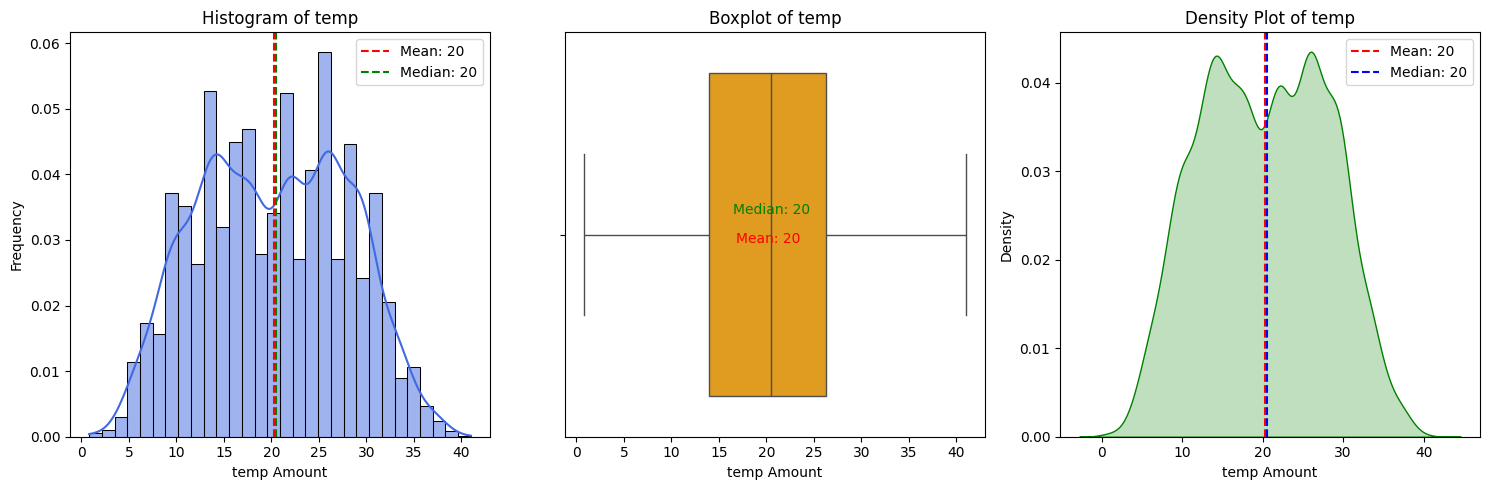

Statistics for atemp:
  Mean   : 23.66
  Median : 24.24
  Std Dev: 8.47
  Min    : 0.76
  Max    : 45.45


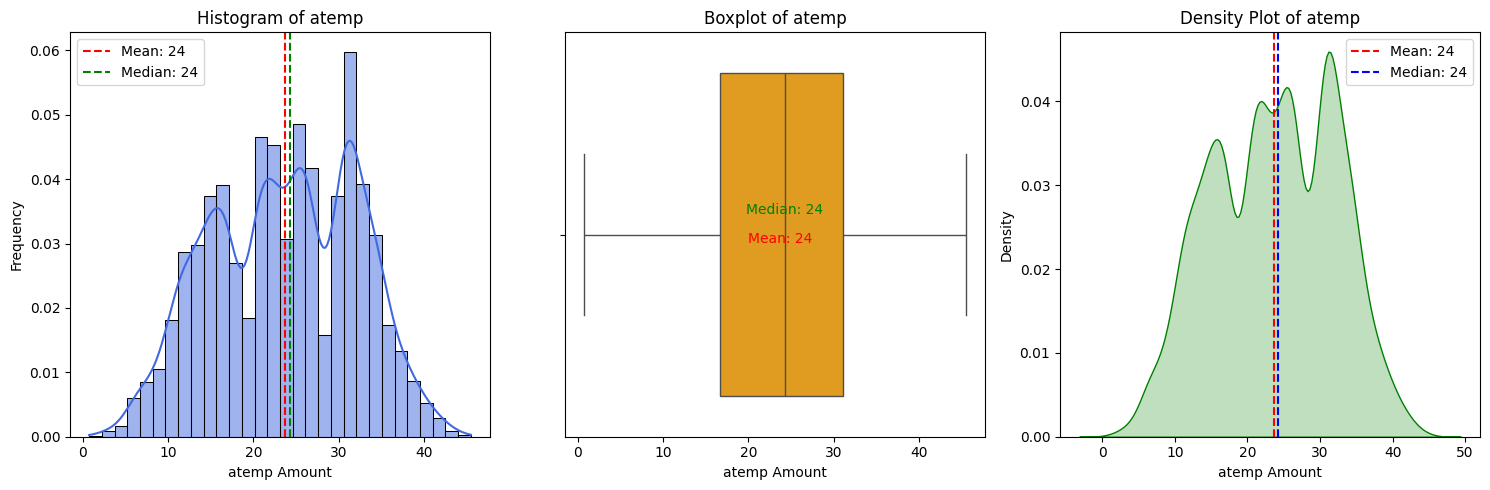

Statistics for humidity:
  Mean   : 61.89
  Median : 62.00
  Std Dev: 19.25
  Min    : 0.00
  Max    : 100.00


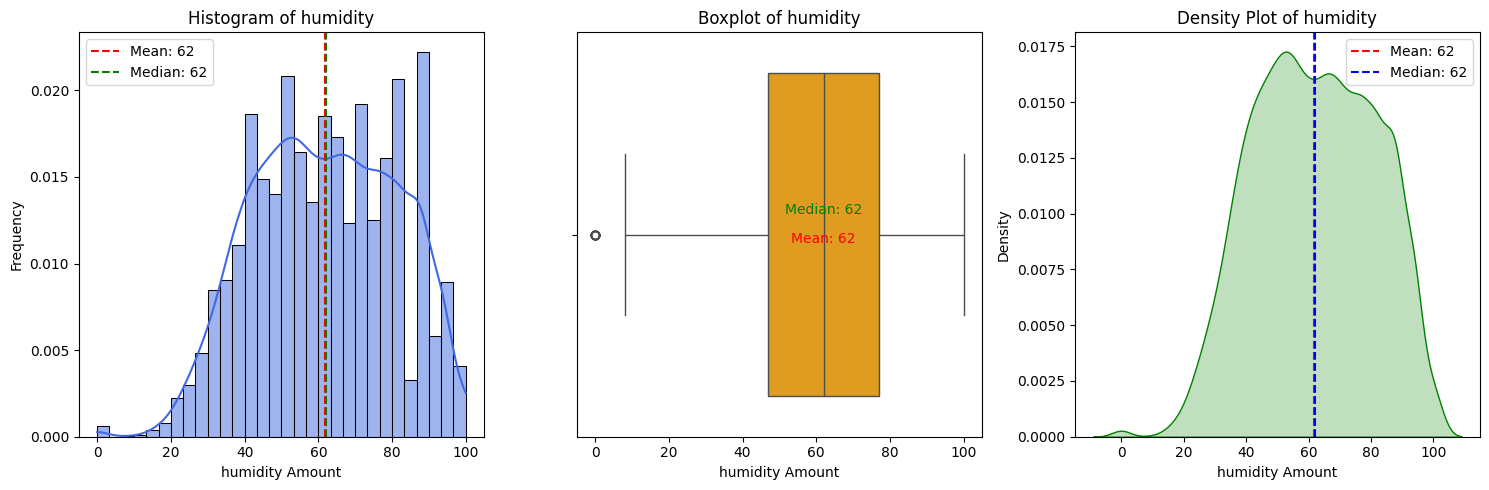

Statistics for windspeed:
  Mean   : 12.80
  Median : 13.00
  Std Dev: 8.16
  Min    : 0.00
  Max    : 57.00


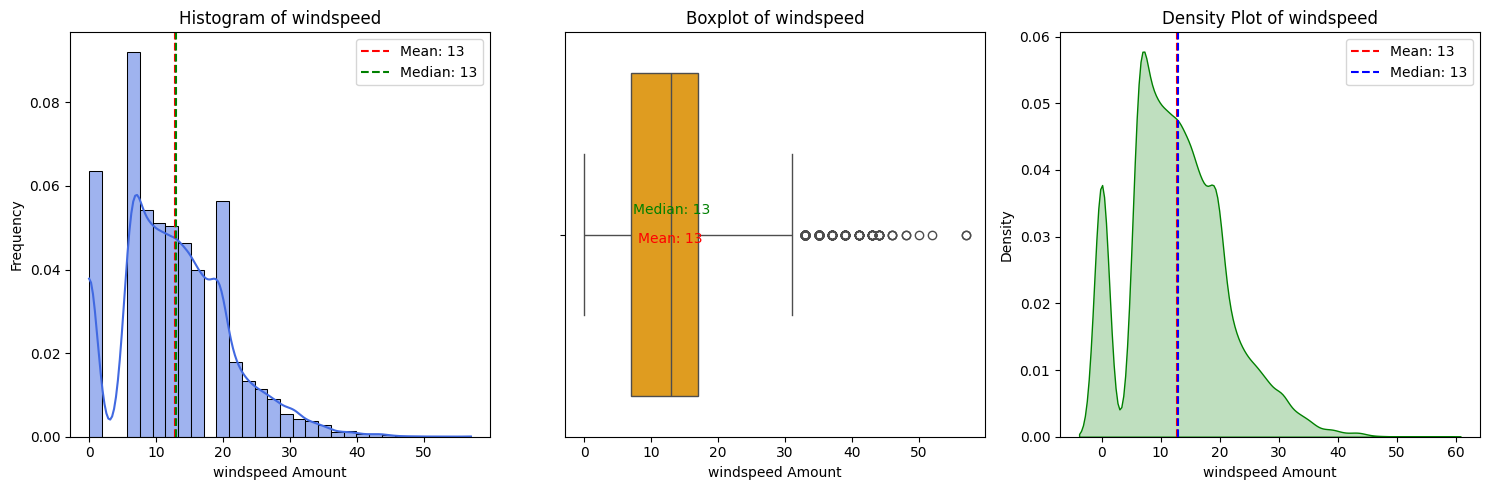

Statistics for casual:
  Mean   : 36.02
  Median : 17.00
  Std Dev: 49.96
  Min    : 0.00
  Max    : 367.00


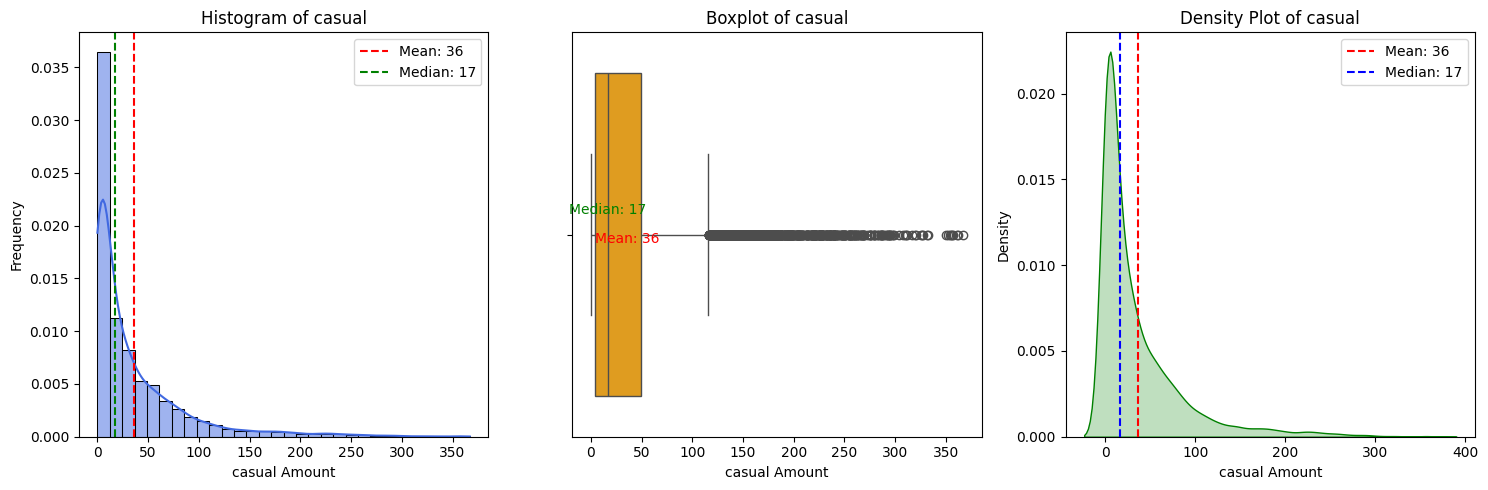

Statistics for registered:
  Mean   : 155.55
  Median : 118.00
  Std Dev: 151.04
  Min    : 0.00
  Max    : 886.00


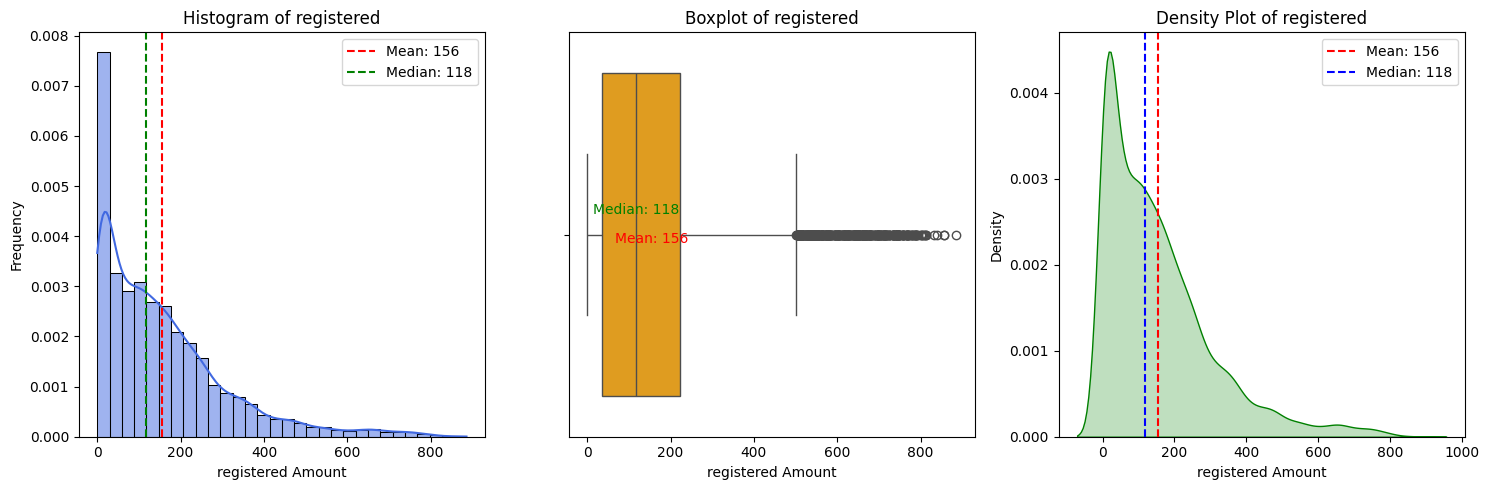

Statistics for count:
  Mean   : 191.57
  Median : 145.00
  Std Dev: 181.14
  Min    : 1.00
  Max    : 977.00


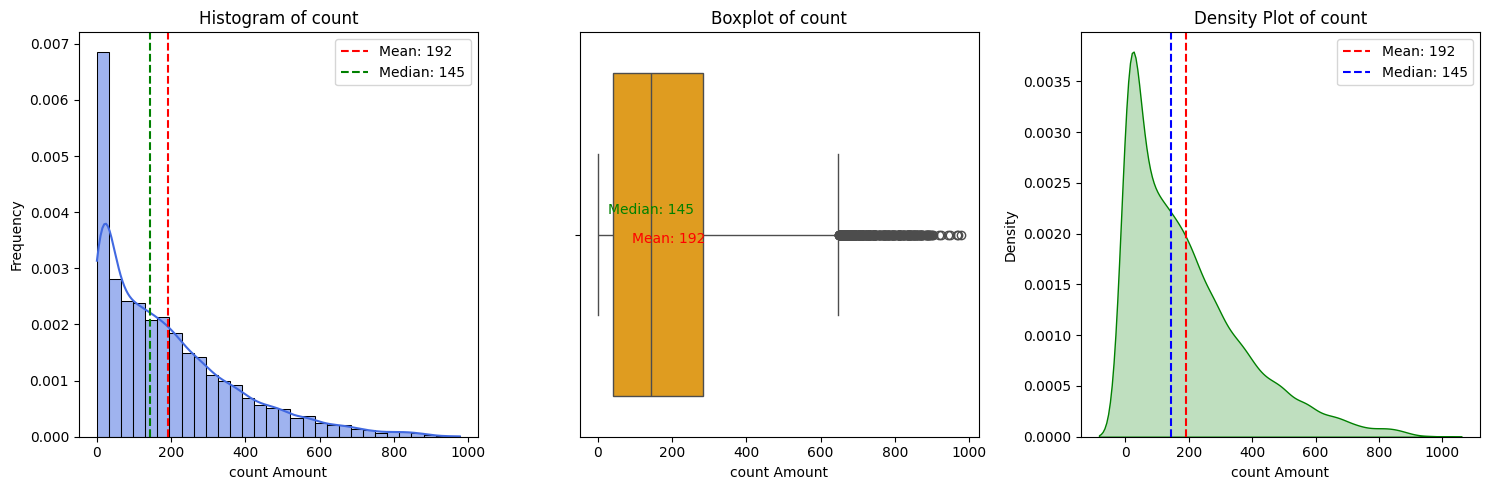

In [55]:
numerical_columns_distribution_with_stats(df)

>Each season (winter, spring, summer, fall) has almost equal observations, meaning rentals are well-distributed across the year.

>Working days (≈68%) dominate the data; non-working days ≈32%.

>Holiday days are very few (≈3%) — this imbalance means holiday effect is minimal overall.

>Weather distribution is highly skewed:

  - Clear/Few clouds days form ~65% of data.

  - Mist or cloudy conditions ≈25%.

  - Rain/Snow days are very rare.

- Because of this imbalance, weather-related rental variations are likely driven mainly by clear vs misty conditions.
- Bike rentals likely drop during mist or cloudy weather, and are highest in clear weather.

>Temperature (temp) ranges from near 0°C to 41°C — wide variation.

- Most common temps: around 15°C–30°C, showing a bell-shaped distribution.

> Perceived temperature (atemp) follows a similar pattern — centered near 25–30°C, which aligns with human comfort.
- Rentals likely increase with temperature up to a comfort threshold (~30°C), then decline due to heat discomfort.

> Humidity varies widely (8–97%), concentrated around 70–90%.
- Very high humidity likely negatively correlates with rentals, as sticky weather reduces bike use.

Many entries have 0.0 windspeed, suggesting sensor dropouts or calm conditions.

> Most windspeed values are below 20 — typical urban conditions.
- Extreme wind (>30) is rare and may cause sharp decline in rentals, but has little global impact due to low frequency.

>Casual users: highly skewed toward low counts (most between 0–10).

- Registered users: much larger counts, up to 800+.

- Total count: right-skewed distribution (many low, few high).
- The system is dominated by regular (registered) users, not casual riders.

>Year: data equally split between 2011 and 2012 → perfect for year-over-year comparison.

>Month: almost uniform distribution, suggesting data covers all months equally.

>Hour: evenly distributed, so likely aggregated hourly.
- Perfect for analyzing hourly and seasonal rental patterns — typically, peaks occur morning 8–9 AM and evening 5–7 PM (to be confirmed by visualization).

>Day of Week: evenly distributed → no data bias toward weekends.

###Bivariate Analysis

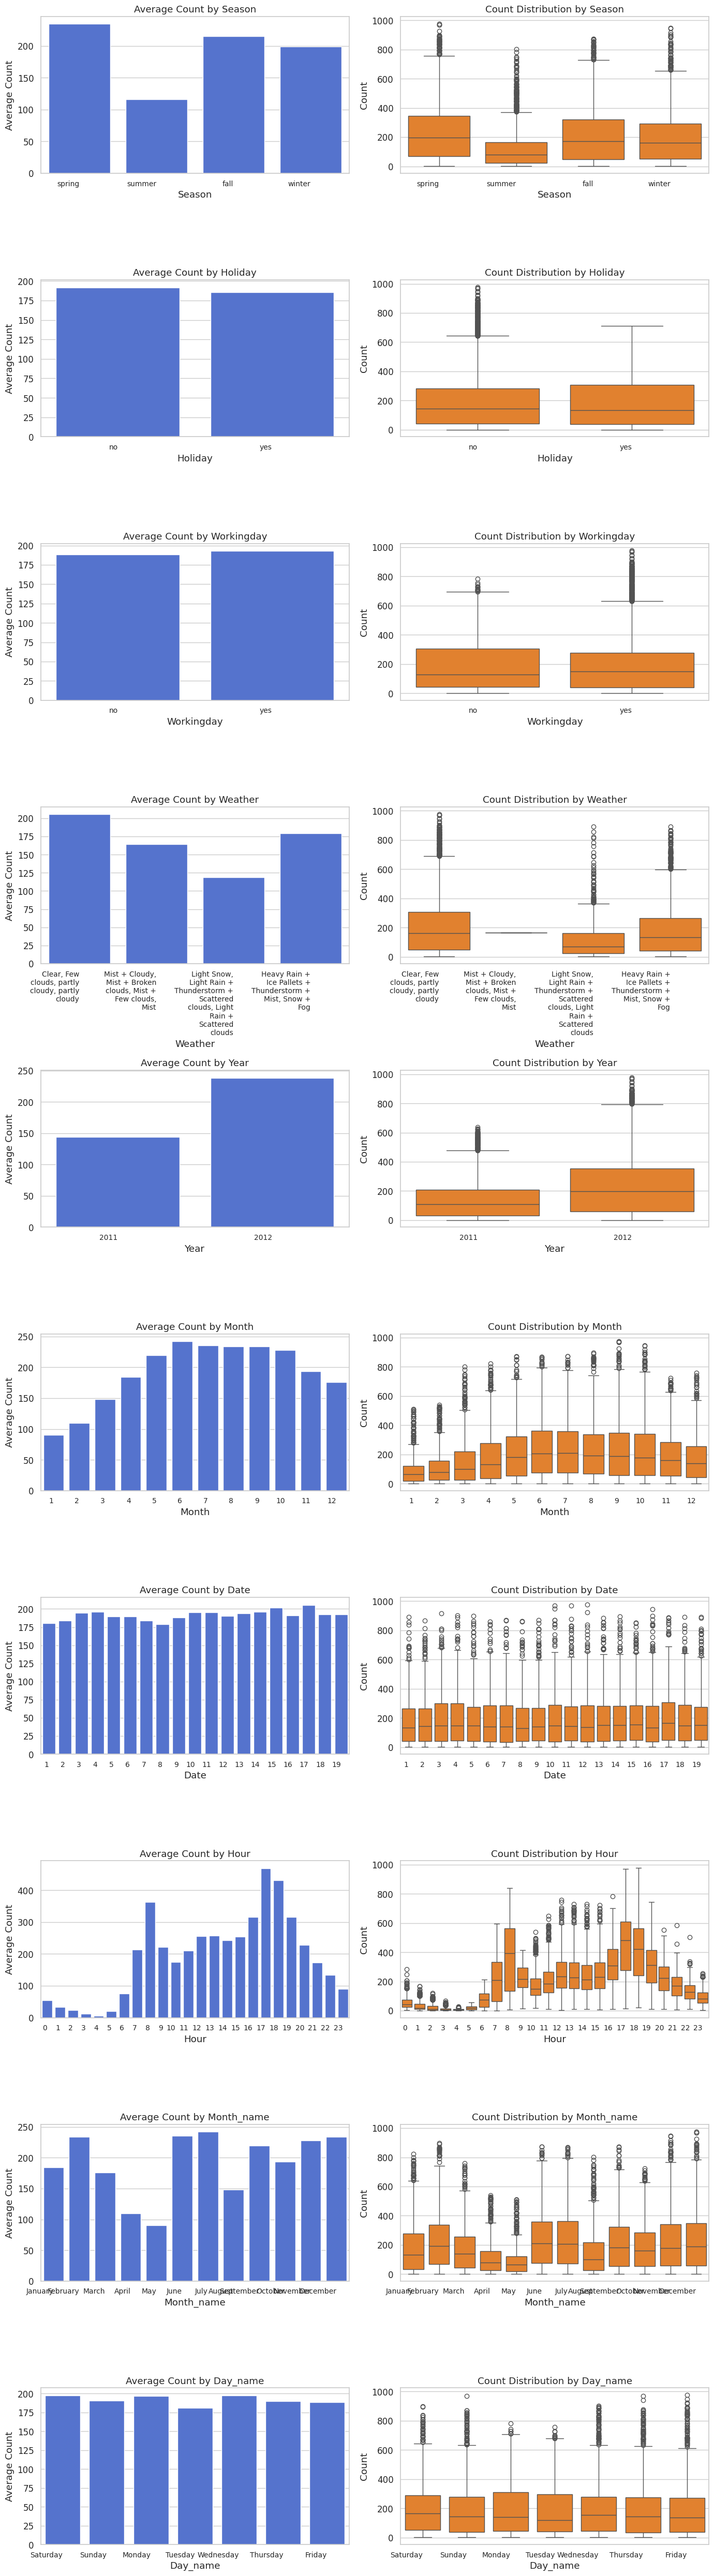

In [56]:
plot_cat(df, cat_cols, target='count')

>Average rental Count is highest in spring and lowest in summer
>While all weather has lots of outliers, summer has the most.

>Average rental Count is same whether its a holiday or not.
>Non-holidays has more outliers compared to holidays

>Same for working day i.e. average rental equal for both working and non-working day
>But no. of outliers higher in working day.

>from 6:00 to 23:59 rental are more with spike in 8:00 hrs and 17:00 hrs to 19:00 hrs may be because of working professionals.
> Also from 6:00 to 9:00 and 16:00 to 21:00 have zero to one or two outliers. Suggesting daily commuters.

>In April & May average bike rental decreases due to heat waves.

>For day of the week monday and tuesday sees less outliers.



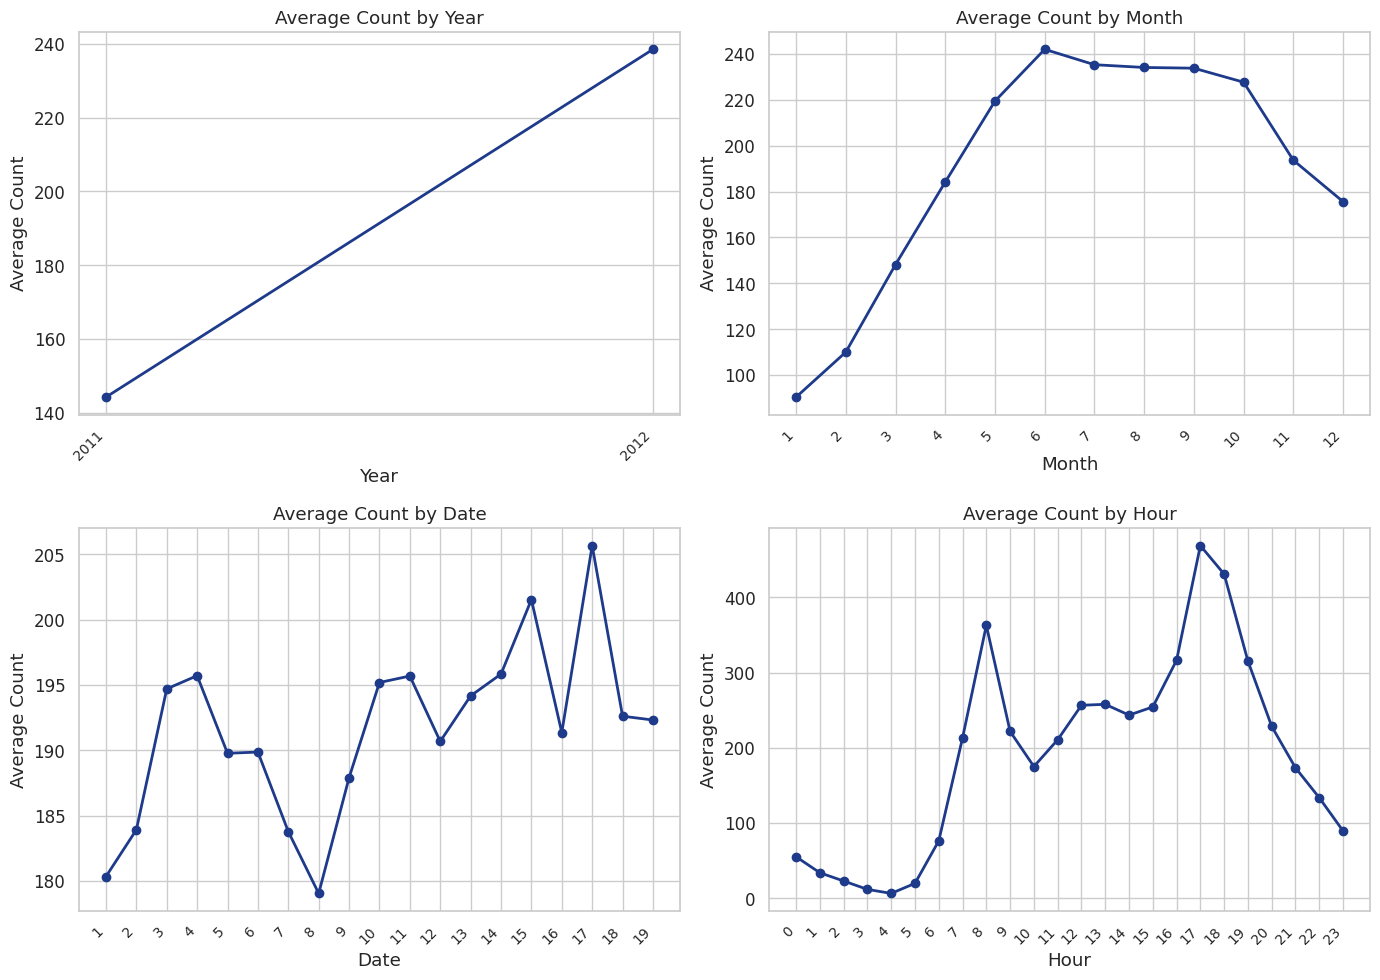

In [57]:
time_cols = ['year', 'month', 'date', 'hour' ]
plot_time_trends(df, time_cols, target='count')

Similar pattern as above bivariate analysis.

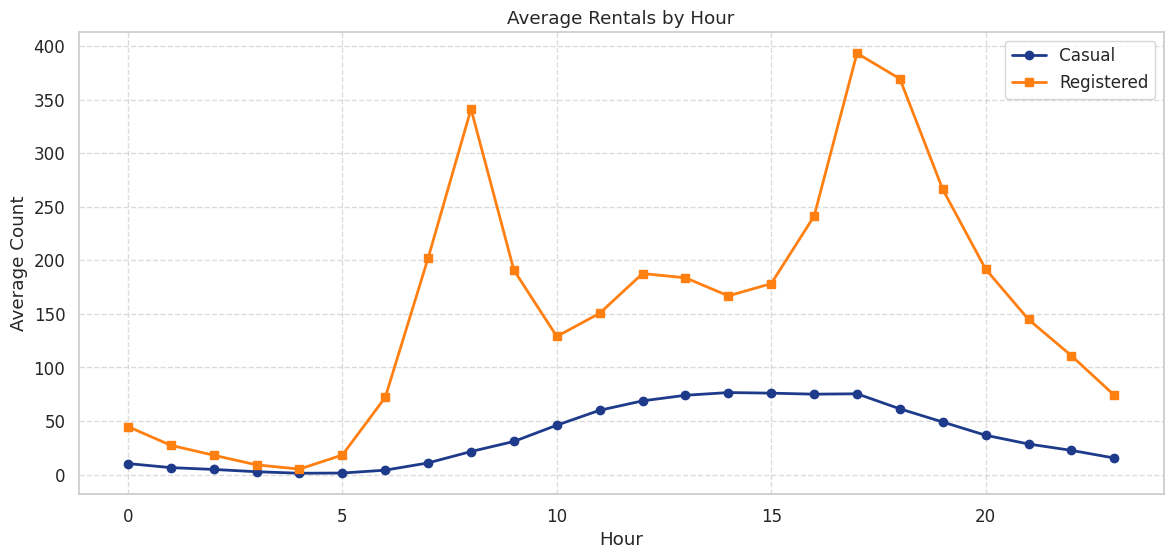

In [58]:

agg_hour = df.groupby('hour', observed=True)[['casual','registered']].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(agg_hour['hour'], agg_hour['casual'], marker='o', color='#1E3A8A', linewidth=2, label='Casual')
plt.plot(agg_hour['hour'], agg_hour['registered'], marker='s', color='#FF7F11', linewidth=2, label='Registered')
plt.title('Average Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


>Average count of registered users higher than casual users most of the hours of the day.

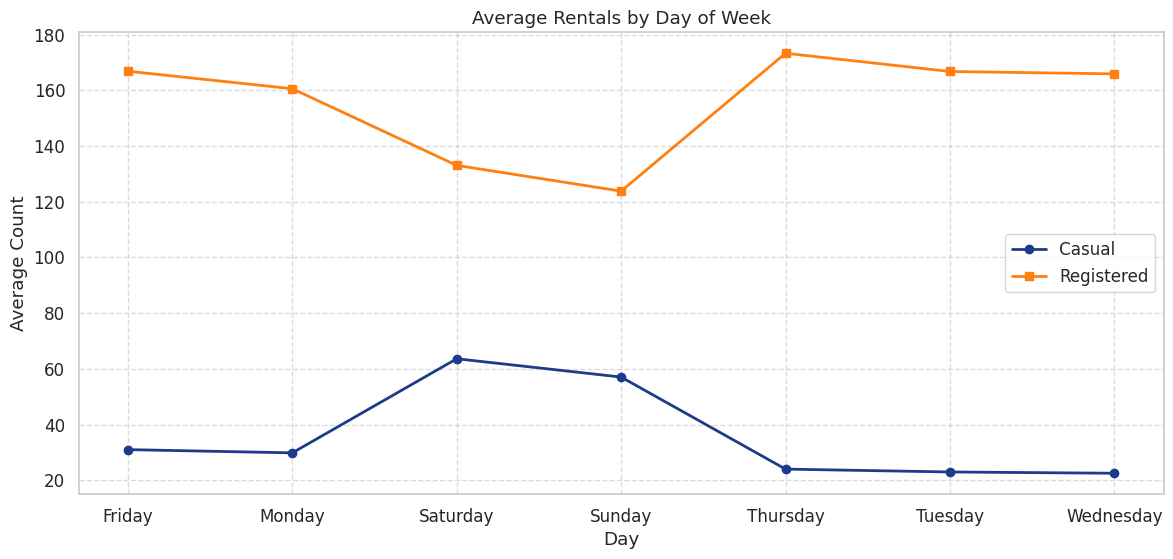

In [59]:
agg_day = df.groupby('day_name', observed=True)[['casual','registered']].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(agg_day['day_name'], agg_day['casual'], marker='o', color='#1E3A8A', linewidth=2, label='Casual')
plt.plot(agg_day['day_name'], agg_day['registered'], marker='s', color='#FF7F11', linewidth=2, label='Registered')
plt.title('Average Rentals by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


>Average use of registered user is high as compared to casual users.

>Usage pattern of reg. users decrease in weekends as compared to weekdays.

>Usage of casual users increase in weekend from week days.


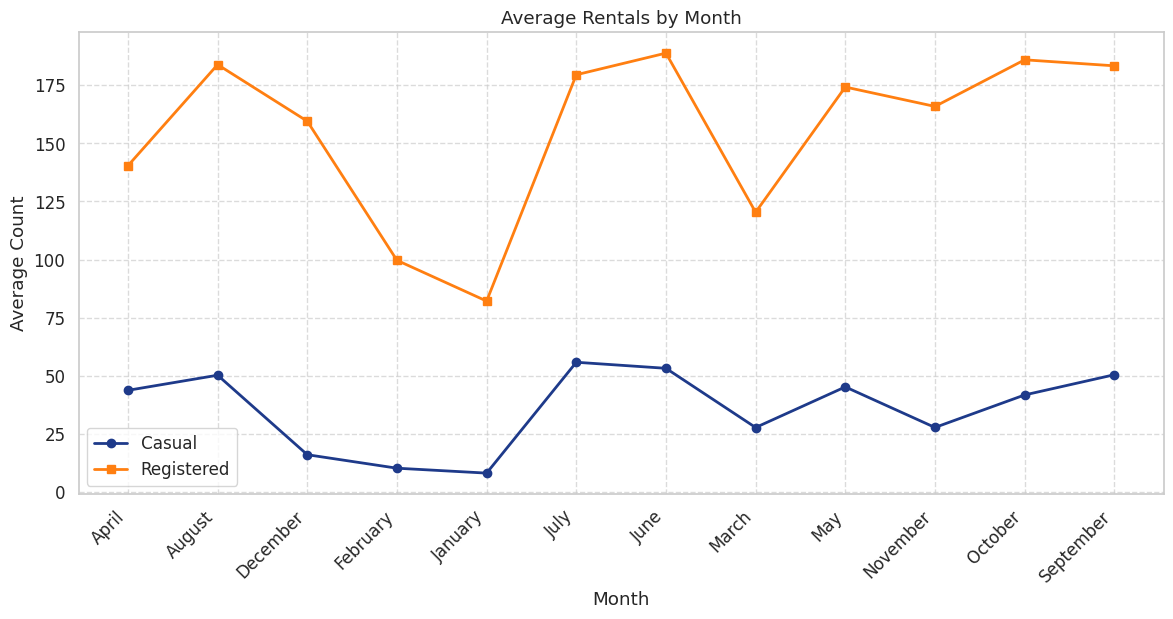

In [60]:
agg_month = df.groupby('month_name', observed=True)[['casual','registered']].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(agg_month['month_name'], agg_month['casual'], marker='o', color='#1E3A8A', linewidth=2, label='Casual')
plt.plot(agg_month['month_name'], agg_month['registered'], marker='s', color='#FF7F11', linewidth=2, label='Registered')
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()


>Even though reg. users usage is higher that casuals but their usage pattern is similar in  months of year.

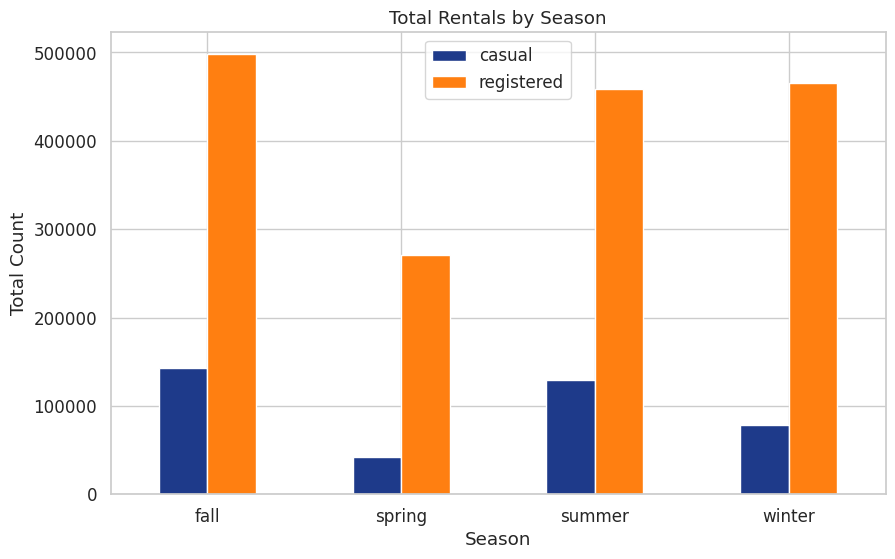

In [61]:
agg_season = df.groupby('season', observed=True)[['casual','registered']].sum().reset_index()

agg_season.plot(x='season', kind='bar', figsize=(10,6), color=['#1E3A8A','#FF7F11'])
plt.title('Total Rentals by Season')
plt.ylabel('Total Count')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.show()


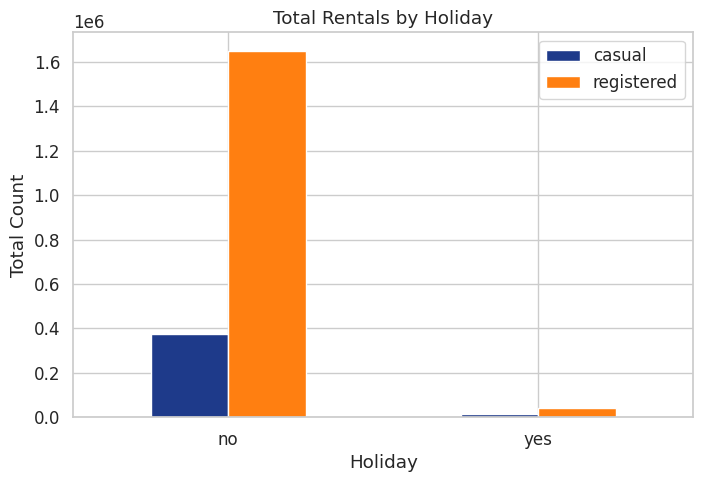

In [62]:
agg_holiday = df.groupby('holiday', observed=True)[['casual','registered']].sum().reset_index()

agg_holiday.plot(x='holiday', kind='bar', figsize=(8,5), color=['#1E3A8A','#FF7F11'])
plt.title('Total Rentals by Holiday')
plt.ylabel('Total Count')
plt.xlabel('Holiday')
plt.xticks(rotation=0)
plt.show()


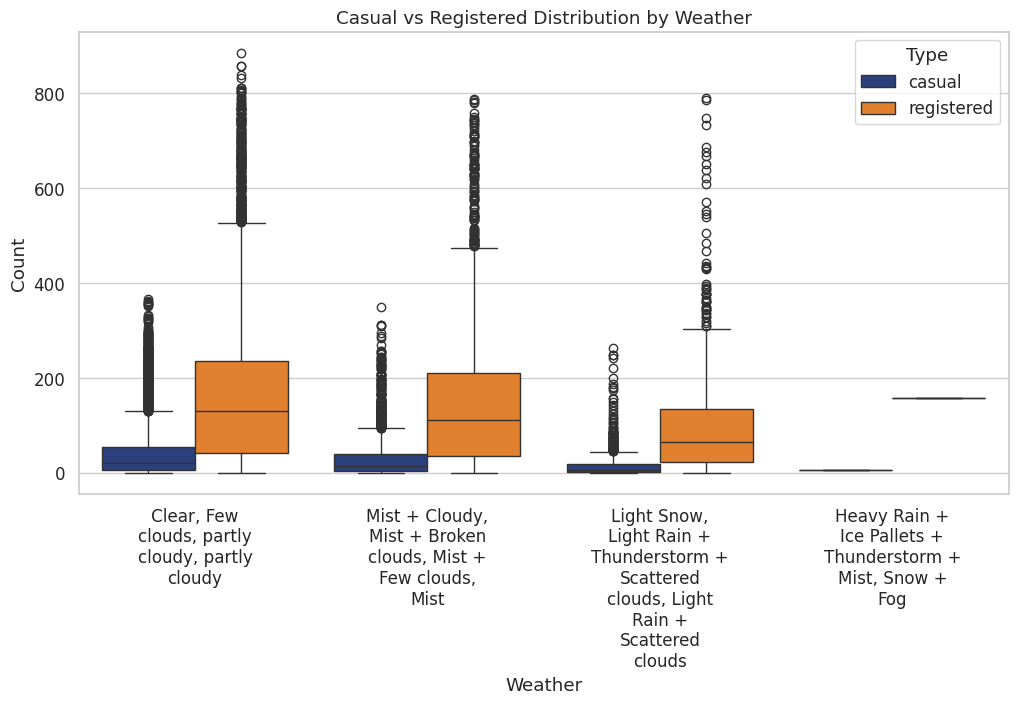

In [63]:
plt.figure(figsize=(12,6))

# Wrap long labels
labels = ["\n".join(textwrap.wrap(str(l), 15)) for l in df['weather'].astype(str)]
df['weather_wrapped'] = labels

# Melt the dataframe to long format for hue
df_melt = df.melt(
    id_vars=['weather_wrapped'],
    value_vars=['casual', 'registered'],
    var_name='type',
    value_name='riders'   # Changed from 'count' to 'riders' to avoid conflict
)

# Plot boxplot with hue
sns.boxplot(
    x='weather_wrapped',
    y='riders',
    hue='type',
    data=df_melt,
    palette={'casual':'#1E3A8A', 'registered':'#FF7F11'}
)

plt.title('Casual vs Registered Distribution by Weather')
plt.ylabel('Count')
plt.xlabel('Weather')
plt.xticks(rotation=0)
plt.legend(title='Type')
plt.show()

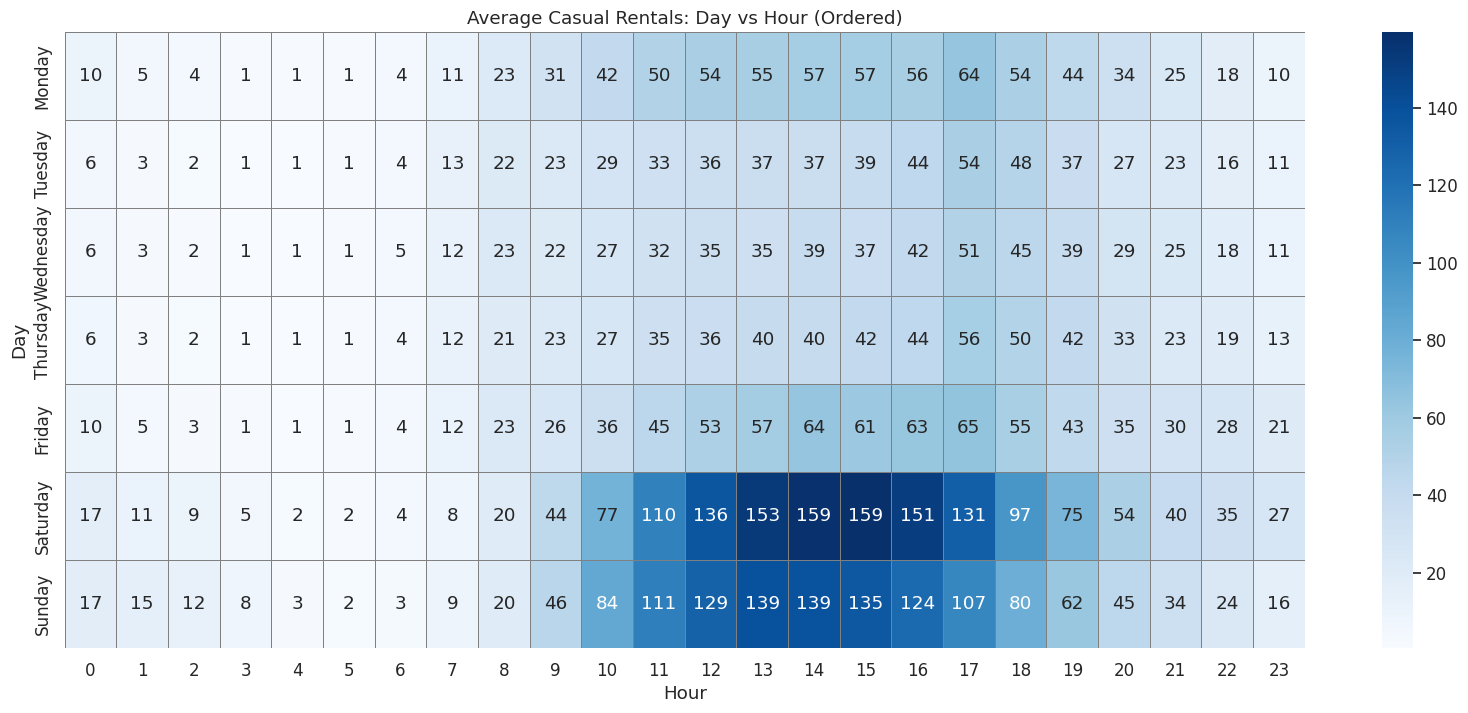

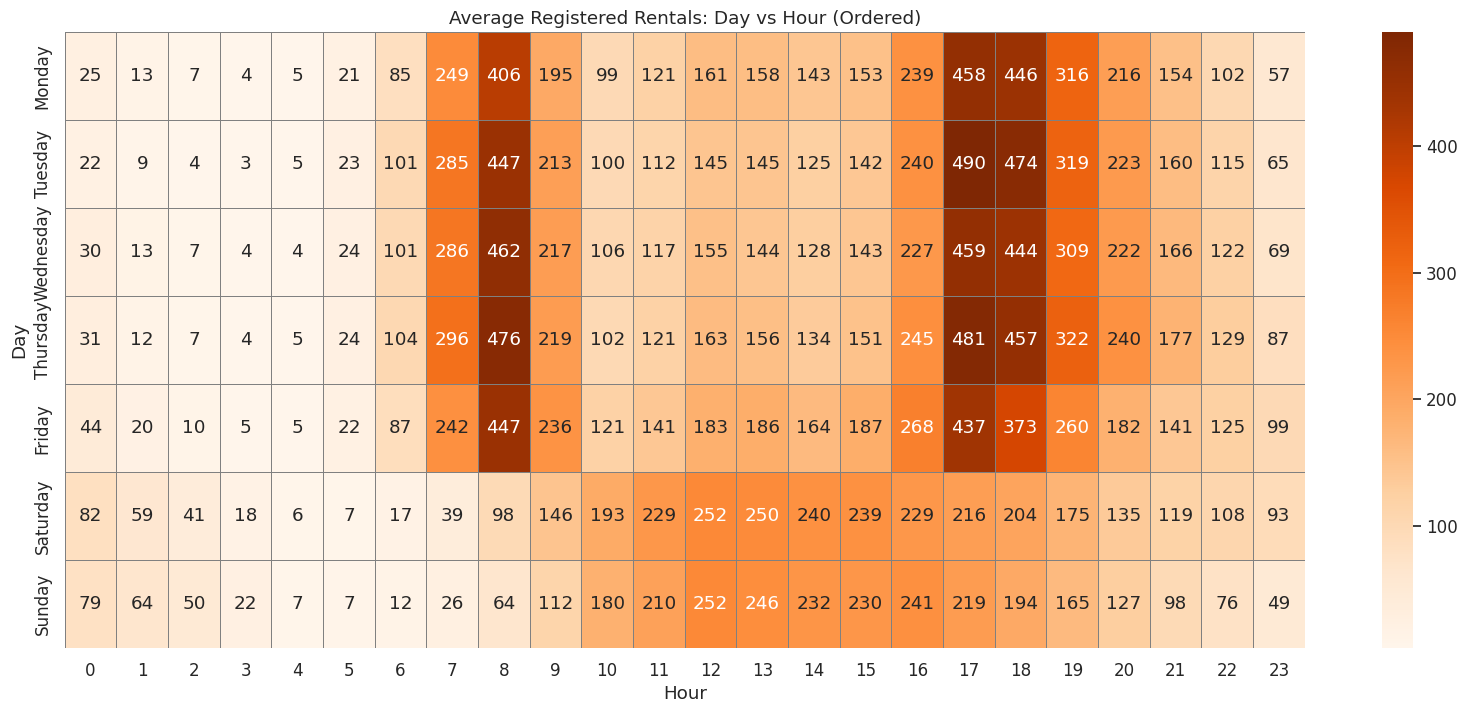

In [64]:

# Define proper order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hours_order = list(range(24))  # 0 to 23

# Pivot tables with ordered categories
pivot_casual = df.pivot_table(
    index='day_name', columns='hour', values='casual', aggfunc='mean', observed=False
).reindex(index=days_order, columns=hours_order)

pivot_registered = df.pivot_table(
    index='day_name', columns='hour', values='registered', aggfunc='mean', observed=False
).reindex(index=days_order, columns=hours_order)

# Casual heatmap
plt.figure(figsize=(20,8))
sns.heatmap(
    pivot_casual, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, linecolor='gray'
)
plt.title('Average Casual Rentals: Day vs Hour (Ordered)')
plt.ylabel('Day')
plt.xlabel('Hour')
plt.show()

# Registered heatmap
plt.figure(figsize=(20,8))
sns.heatmap(
    pivot_registered, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5, linecolor='gray'
)
plt.title('Average Registered Rentals: Day vs Hour (Ordered)')
plt.ylabel('Day')
plt.xlabel('Hour')
plt.show()


> Casual user most active in weekend during 9:00 to 17:00.

>Reg. users most active in weekdays from 6:00 to 9:00 and 16: to 20:00.

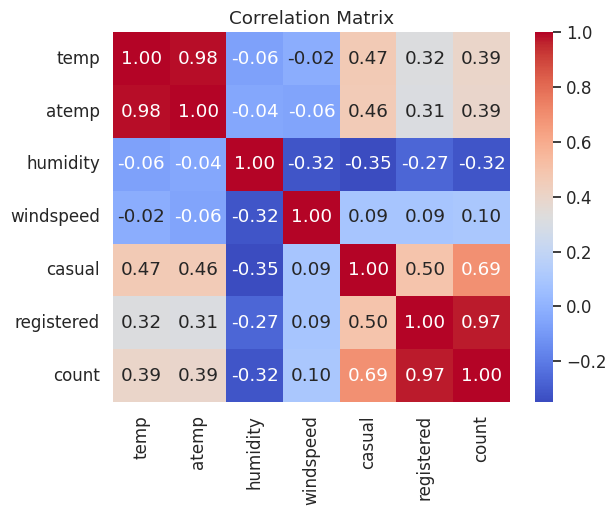

In [65]:
corr = df[['temp','atemp','humidity','windspeed','casual','registered','count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


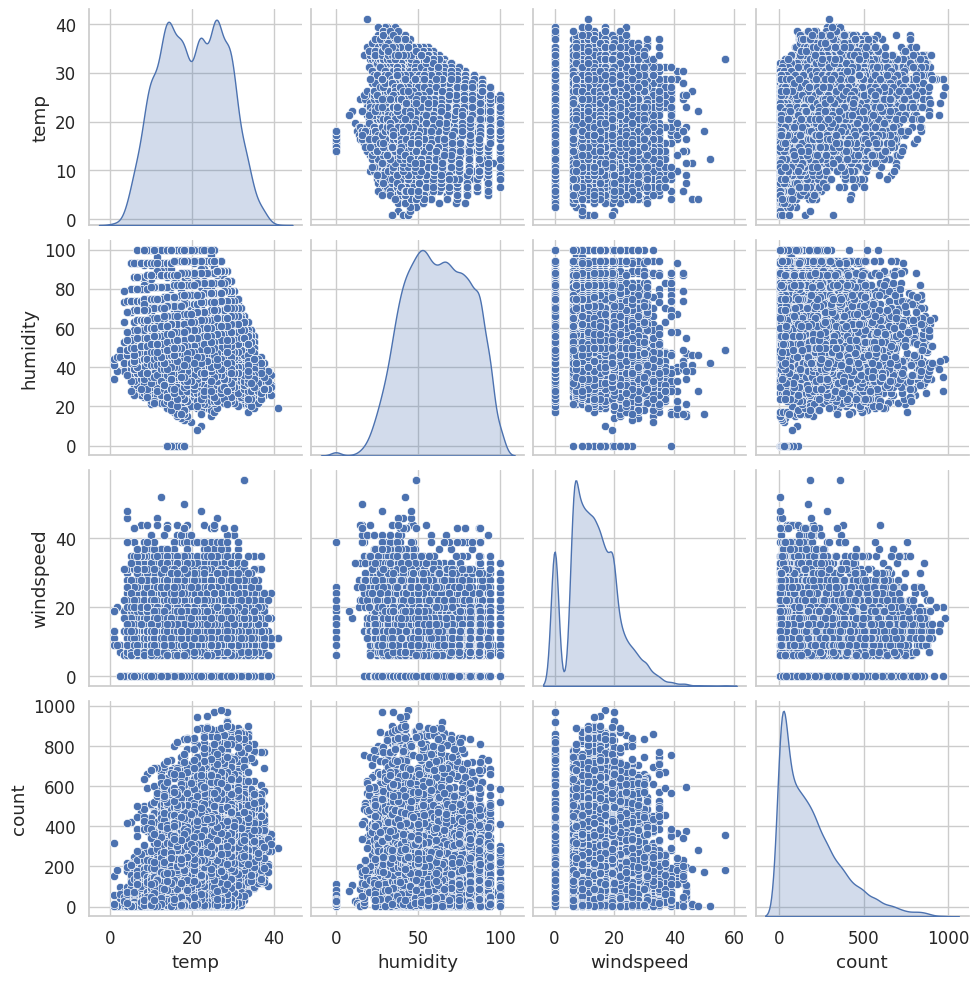

In [66]:
sns.pairplot(df[['temp','humidity','windspeed','count']], diag_kind='kde')
plt.show()

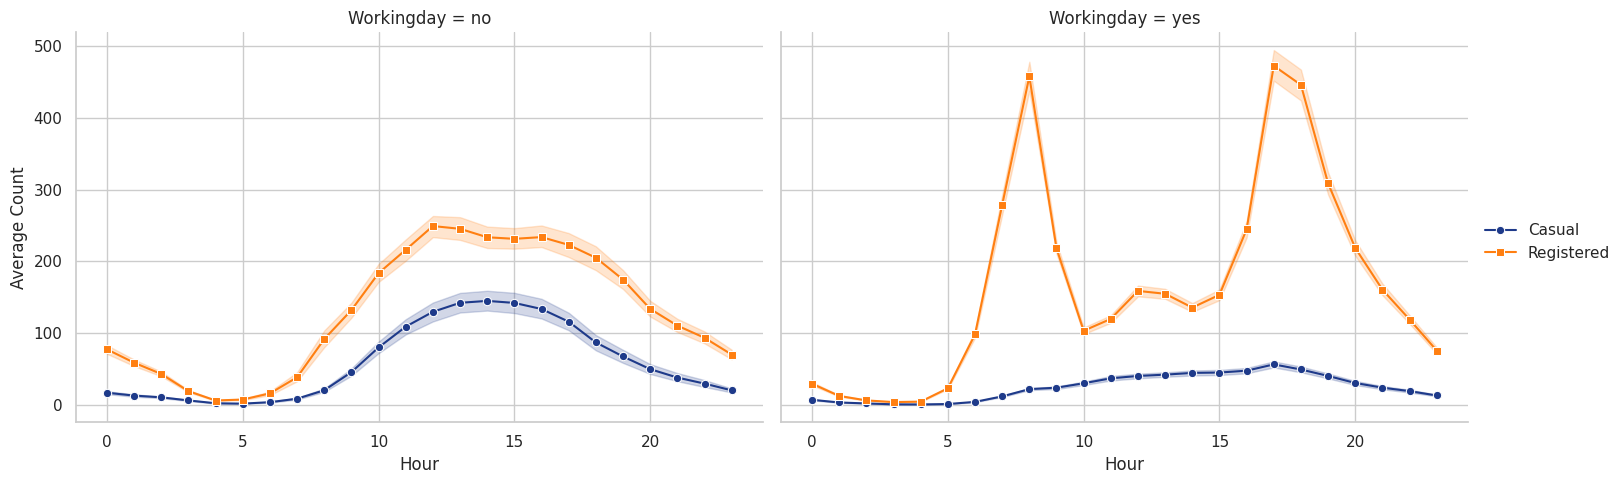

In [67]:
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df, col='workingday', height=5, aspect=1.5)
g.map_dataframe(sns.lineplot, x='hour', y='casual', marker='o', color='#1E3A8A', label='Casual')
g.map_dataframe(sns.lineplot, x='hour', y='registered', marker='s', color='#FF7F11', label='Registered')
g.set_axis_labels('Hour', 'Average Count')
g.add_legend()
g.set_titles('Workingday = {col_name}')
plt.show()


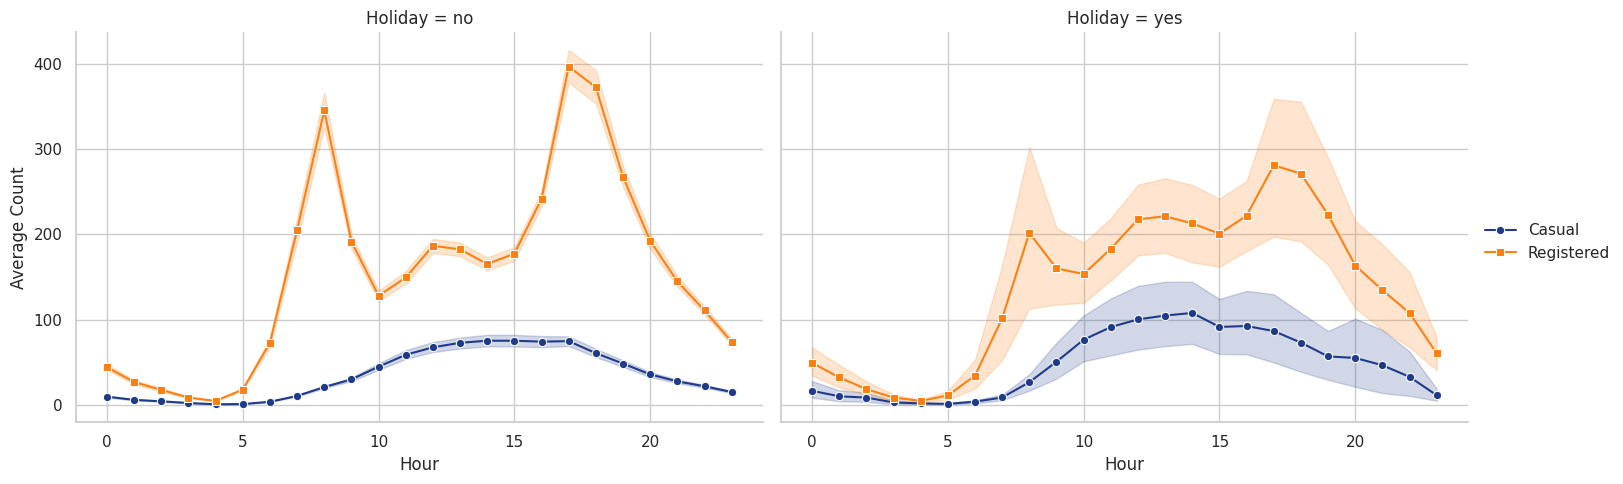

In [68]:
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df, col='holiday', height=5, aspect=1.5)
g.map_dataframe(sns.lineplot, x='hour', y='casual', marker='o', color='#1E3A8A', label='Casual')
g.map_dataframe(sns.lineplot, x='hour', y='registered', marker='s', color='#FF7F11', label='Registered')
g.set_axis_labels('Hour', 'Average Count')
g.add_legend()
g.set_titles('Holiday = {col_name}')
plt.show()

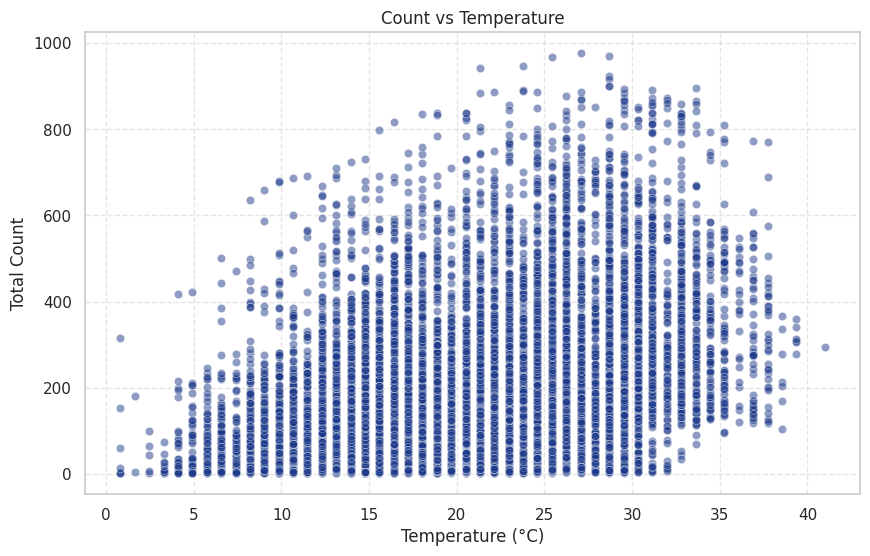

In [69]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='temp', y='count', data=df, alpha=0.5, color='#1E3A8A')
plt.title('Count vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


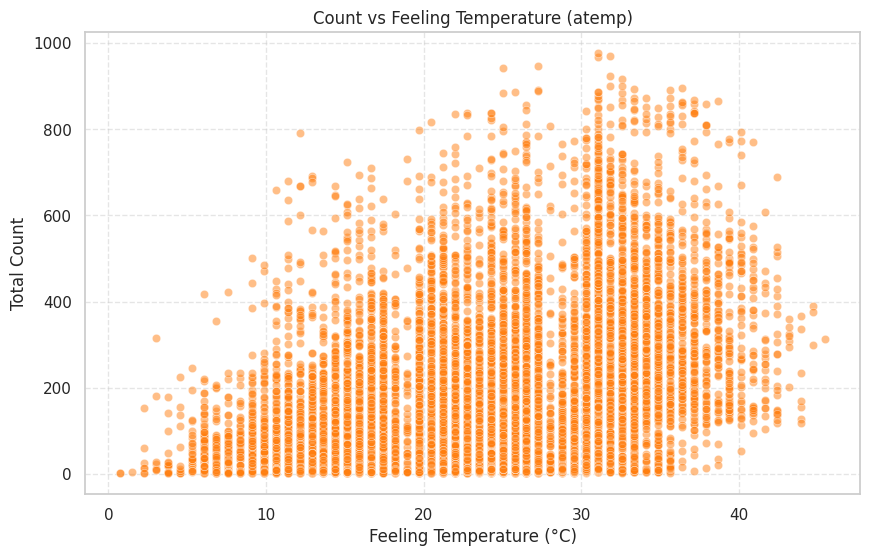

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='atemp', y='count', data=df, alpha=0.5, color='#FF7F11')
plt.title('Count vs Feeling Temperature (atemp)')
plt.xlabel('Feeling Temperature (°C)')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


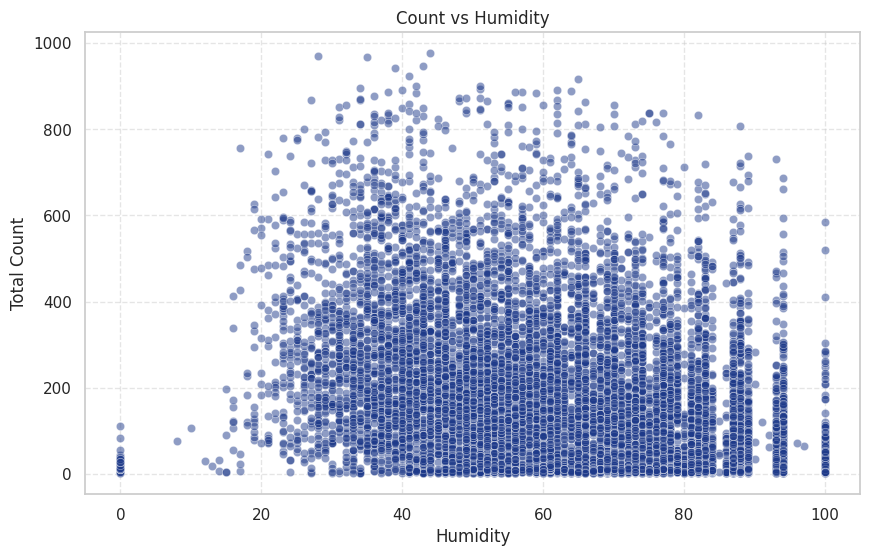

In [71]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='humidity', y='count', data=df, alpha=0.5, color='#1E3A8A')
plt.title('Count vs Humidity')
plt.xlabel('Humidity')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


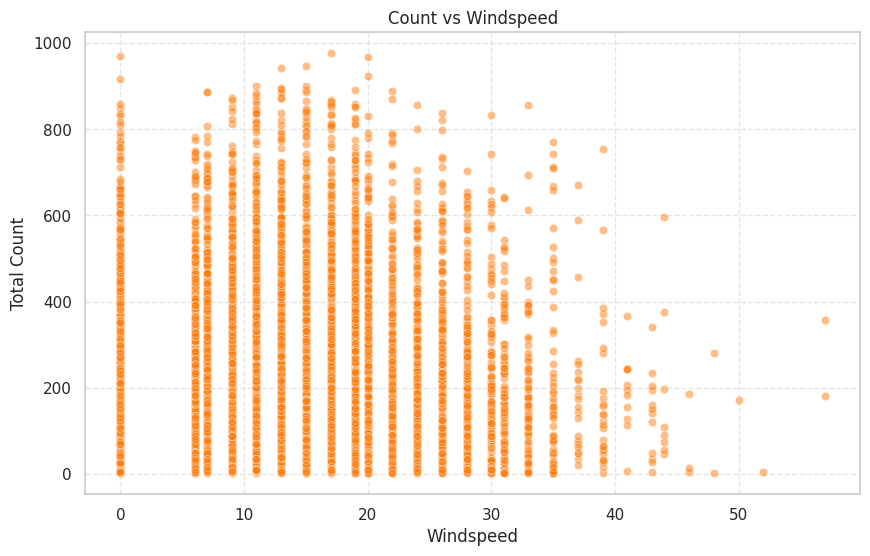

In [72]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='windspeed', y='count', data=df, alpha=0.5, color='#FF7F11')
plt.title('Count vs Windspeed')
plt.xlabel('Windspeed')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#Missing Value & Outlier Detection

In [73]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [75]:
outlier_summary = detect_outliers_iqr(df)
pd.DataFrame(outlier_summary).T

,outlier_count,lower_bound,upper_bound,min_value,max_value,possible_errors
temp,0,-4.51,44.69,0.82,41.0,[]
atemp,0,-4.9275,52.6525,0.76,45.455,[]
humidity,22,2.0,122.0,0,100,[]
windspeed,227,-7.9931,31.9925,0.0,56.9969,[]
casual,749,-63.5,116.5,0,367,[]
registered,423,-243.0,501.0,0,886,[]
count,300,-321.0,647.0,1,977,[]



Column: temp
Number of outliers (IQR method): 0


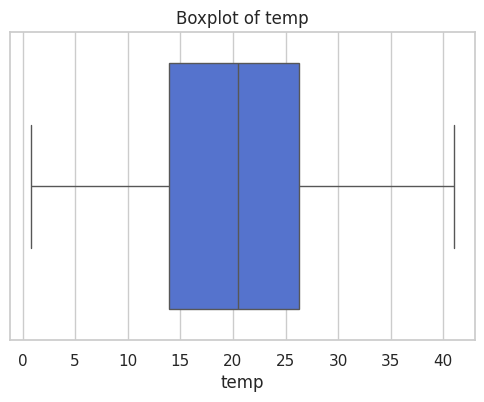


Column: atemp
Number of outliers (IQR method): 0


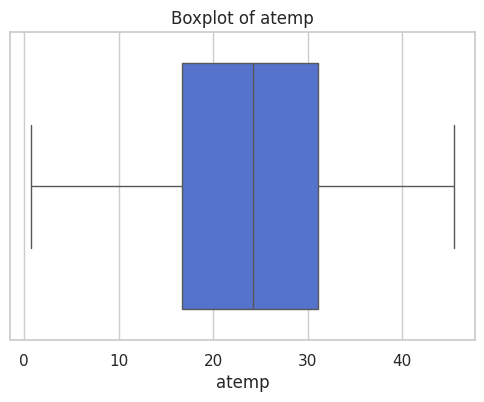


Column: humidity
Number of outliers (IQR method): 22


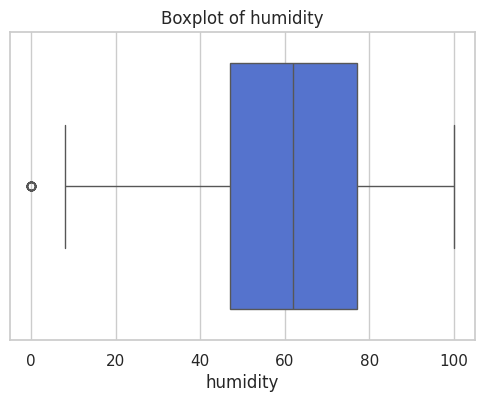


Column: windspeed
Number of outliers (IQR method): 227


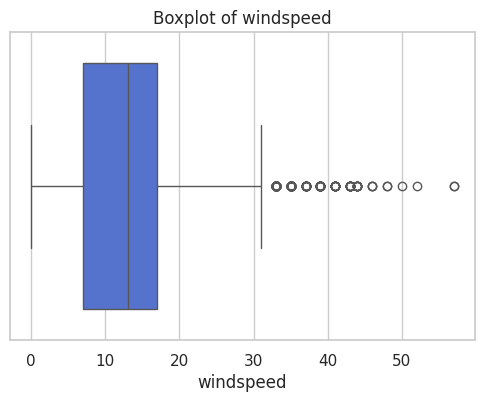


Column: casual
Number of outliers (IQR method): 749


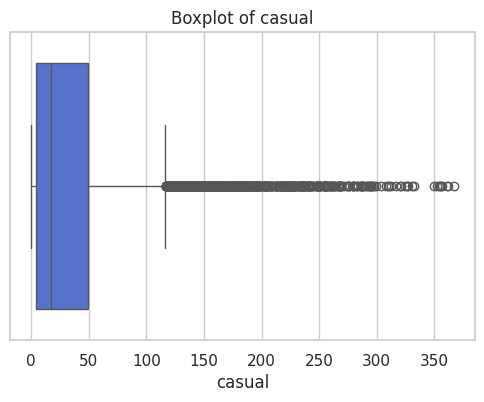


Column: registered
Number of outliers (IQR method): 423


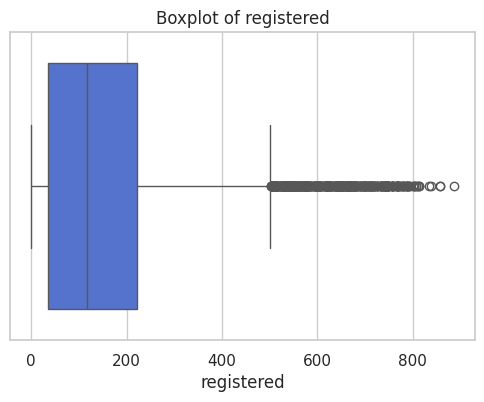


Column: count
Number of outliers (IQR method): 300


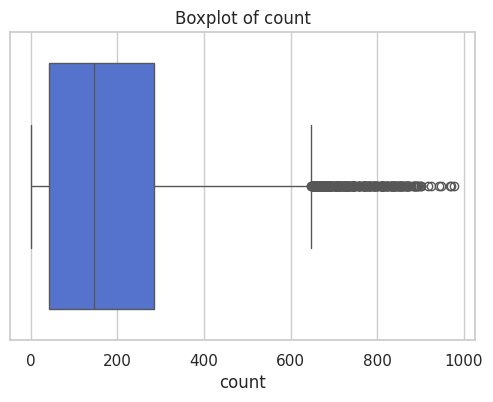

In [74]:
iqr_outliers_boxplot(df)

#Hypothesis Testing

##Q-1
---
>Check if there any significant difference between the no. of bike rides on Weekdays
and Weekends?

---




Ho :

 There is no significant difference in the mean number of bike rides between weekdays and weekends. i.e. $\mu_{\text{weekday}} = \mu_{\text{weekend}}$

<br>
Ha :

There is a significant difference in the mean number of bike rides between weekdays and weekends. i.e.
$\mu_{\text{weekday}} \neq \mu_{\text{weekend}}$

In [76]:
alpha=0.05

In [77]:
weekdays_rides=df[df['day_name'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]
weekends_rides=df[df['day_name'].isin(['Saturday', 'Sunday'])]

weekdays_rides['count'].sum(), weekends_rides['count'].sum(),df['count'].sum()

(np.int64(1488412), np.int64(597064), np.int64(2085476))

In [78]:
weekdays_rides=weekdays_rides['count']
weekends_rides=weekends_rides['count']

len(weekdays_rides), len(weekends_rides)

(7723, 3163)

In [79]:
weekdays_rides.var()/weekends_rides.var()

1.1133500509441068

In [80]:
'''
Ho: equal variance i.e. weekdays_rides.var() = weekends_rides.var()
Ha: unequal variance i.e. weekdays_rides.var() != weekends_rides.var()
'''
_, p = levene(weekdays_rides, weekends_rides)
check(p, alpha)

p =  0.955218859658268
alpha =  0.05 

p > alpha

Fail to reject Ho



As you can see the ratio of  larger variance to smaller variane is less than 2 and also levene test shows both data set have equal variance

so the `equal_var=True`

In [81]:
t_stat, p_value = ttest_ind(weekdays_rides, weekends_rides, equal_var=True)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.0354386367292092
p-value: 0.3004871142922829


In [82]:
check(p_value, alpha)

p =  0.3004871142922829
alpha =  0.05 

p > alpha

Fail to reject Ho



###Inference

The average number of bike rides on weekdays and weekends are not significantly different.
This suggests that riding patterns remain fairly consistent throughout the week, and the day type (weekday vs weekend) does not have a strong influence on total ride counts

###Business Recommendation

- Maintain similar bike availability, staffing, and maintenance schedules across all days since ride demand remains stable.

- Avoid unnecessary operational adjustments or extra staffing on weekends, which can help reduce costs.


##Q-2
---
>Check if the demand of bicycles on rent is the same for different Weather
conditions?
---

- Null hypothesis (H₀): The mean number of bicycles rented is the same across all weather conditions.

- Alternative hypothesis (H₁): At least one weather condition has a different mean number of bicycles rented.

In [83]:
weather = { 1: "Clear, Few clouds, partly cloudy, partly cloudy",
            2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist",
            3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds",
            4: "Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog"
          }

In [84]:
alpha=0.5

In [85]:
weather_1 = df[df['weather'] == weather[1]]['count']
weather_2 = df[df['weather'] == weather[2]]['count']
weather_3 = df[df['weather'] == weather[3]]['count']
weather_4 = df[df['weather'] == weather[4]]['count']

In [86]:
datasets = [weather_1, weather_2, weather_3, weather_4]


###Normality Test

####Histogram

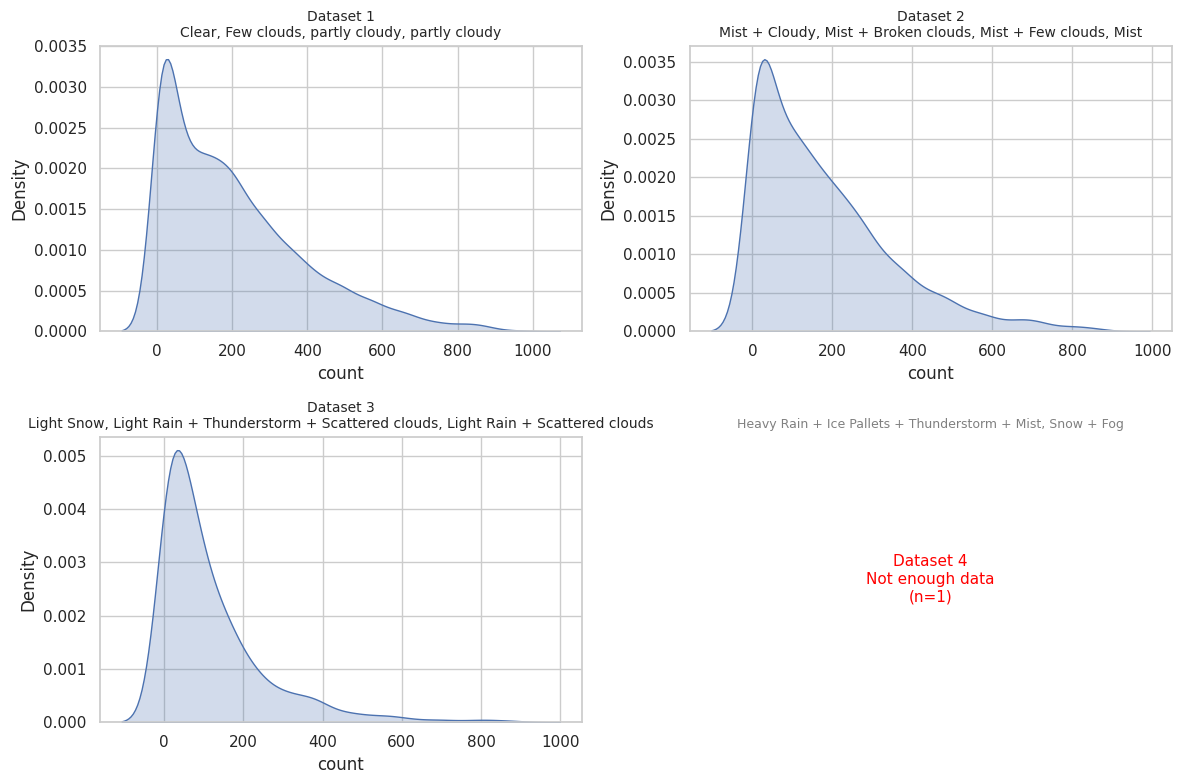

In [87]:
plot_kde(datasets, weather)

####Q-Q Plot

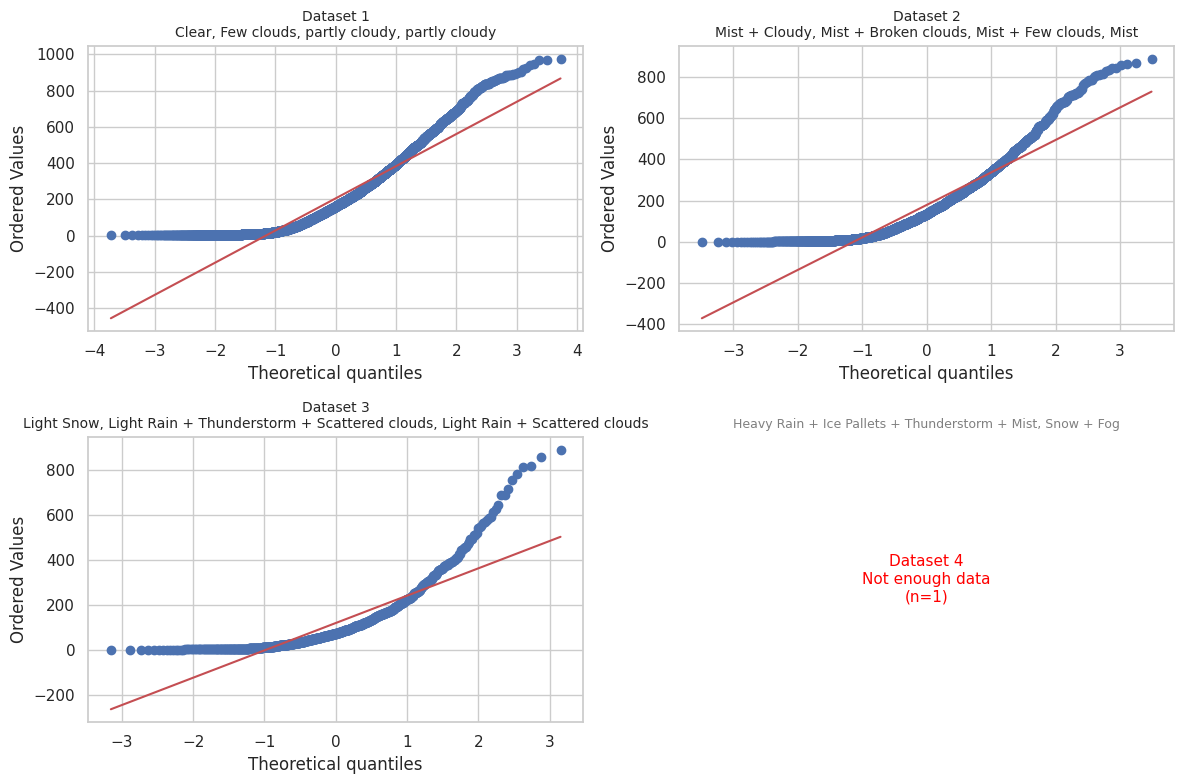

In [88]:
plot_qq(datasets, weather)

####Skew and Kurt

In [89]:
weather_1.skew(), weather_2.skew(), weather_3.skew(), weather_4.skew()

(np.float64(1.1398572666918205),
 np.float64(1.294444423357868),
 np.float64(2.1871371080456594),
 nan)

In [90]:
weather_1.kurtosis(), weather_2.kurtosis(), weather_3.kurtosis(), weather_4.kurtosis()

(np.float64(0.964719852310354),
 np.float64(1.5884304891319174),
 np.float64(6.003053730759276),
 nan)

####Shapiro-Wilks test

For Shapiro-Wilks test for normality

Ho : Gaussian or Normal Dist.

Ha : Not Normal Dist.

In [91]:
alpha=0.05

In [92]:
_, p = shapiro(weather_1)
check(p, alpha)

p =  1.5964921477006555e-57
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


In [93]:
_, p = shapiro(weather_2)
check(p, alpha)

p =  9.777839106111785e-43
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [94]:
_, p = shapiro(weather_3)
check(p, alpha)

p =  3.875893017396149e-33
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [95]:
_, p = shapiro(weather_4)
check(p, alpha)

p =  nan
alpha =  0.05 

p > alpha

Fail to reject Ho



/tmp/ipython-input-4214370266.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = shapiro(weather_4)


###Variance Test

Ho : Variances are relatively equal across the groups

Ha : Variances significantly differ across the groups

In [96]:
levene_stat, p_value = levene(weather_1, weather_2, weather_3, weather_4)
print("Levene's statistic:", levene_stat)
print("p-value:", p_value)

Levene's statistic: 54.85106195954556
p-value: 3.504937946833238e-35


In [97]:
check(p_value, alpha)

p =  3.504937946833238e-35
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Hypothesis Testing

####F_oneway(ANOVA)

- Null hypothesis (H₀): The mean number of bicycles rented is the same across all weather conditions.

- Alternative hypothesis (H₁): At least one weather condition has a different mean number of bicycles rented.

In [98]:
_, p = f_oneway(weather_1, weather_2, weather_3, weather_4)
check(p, alpha)

p =  5.482069475935669e-42
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


####Kruskal

**Null Hypothesis (H0):**


  * In other words, there is no statistically significant difference in the medians of the groups being compared.

**Alternative Hypothesis (H1):**

  * There is a statistically significant difference in the medians of at least two groups.


In [99]:
_, p = kruskal(weather_1, weather_2, weather_3, weather_4)
check(p, alpha)

p =  3.501611300708679e-44
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Inference

This indicates that bicycle rental demand is not the same across different weather conditions. At least one weather type has a significantly different average demand.

###Business Recommendation

- Plan operations based on weather patterns: Allocate more bikes and staff on favorable weather days.

- Monitor weather forecasts to adjust fleet availability dynamically.

- Consider incentives or promotions on low-demand weather days to maintain utilization.


The number of bicycle rentals varies significantly across different weather conditions:

- Clear/Few/Partly Cloudy: 7,192 rentals

- Mist/Cloudy: 2,834 rentals

- Light Snow / Light Rain / Thunderstorm: 859 rentals

- Heavy Rain / Ice Pellets / Snow + Fog: 1 rental

An ANOVA test confirms that these differences are statistically significant (p < 0.05), indicating that weather strongly influences rental demand. Clear and partly cloudy days see the highest rentals, while extreme weather conditions drastically reduce demand.

Recommendation:

>Allocate more bikes and staff on clear or partly cloudy days to meet higher demand.

>Reduce operational load during misty or rainy conditions to save costs.

>Plan promotions or incentives to encourage rentals during low-demand weather.

>Continuously monitor weather forecasts and historical ridership to optimize daily operations.

##Q-3
---
>Check if the demand of bicycles on rent is the same for different Seasons?
---

**Null Hypothesis (H₀):**  
The mean number of bicycles rented is the same across all seasons.  
*μ<sub>Spring</sub> = μ<sub>Summer</sub> = μ<sub>Fall</sub> = μ<sub>Winter</sub>*

<br>

**Alternative Hypothesis (H₁):**  
At least one season has a different mean number of bicycles rented.  
*At least one μ<sub>season</sub> is different*

In [100]:
spring=df[df['season']=='spring']['count']
summer=df[df['season']=='summer']['count']
fall=df[df['season']=='fall']['count']
winter=df[df['season']=='winter']['count']

spring.shape, summer.shape, fall.shape, winter.shape

((2686,), (2733,), (2733,), (2734,))

In [101]:
datasets = [spring, summer, fall, winter]

In [102]:
season = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}

###Normality Test

####Histogram

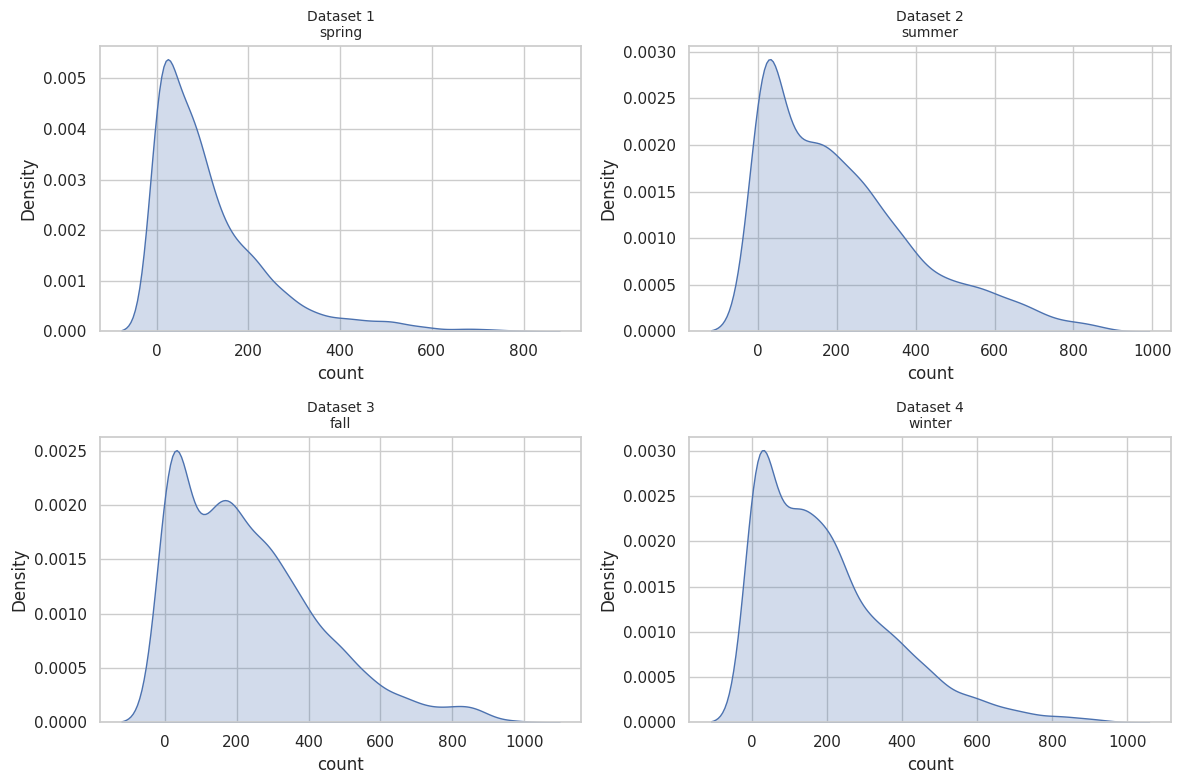

In [103]:
plot_kde(datasets, season)

####Q-Q Plot

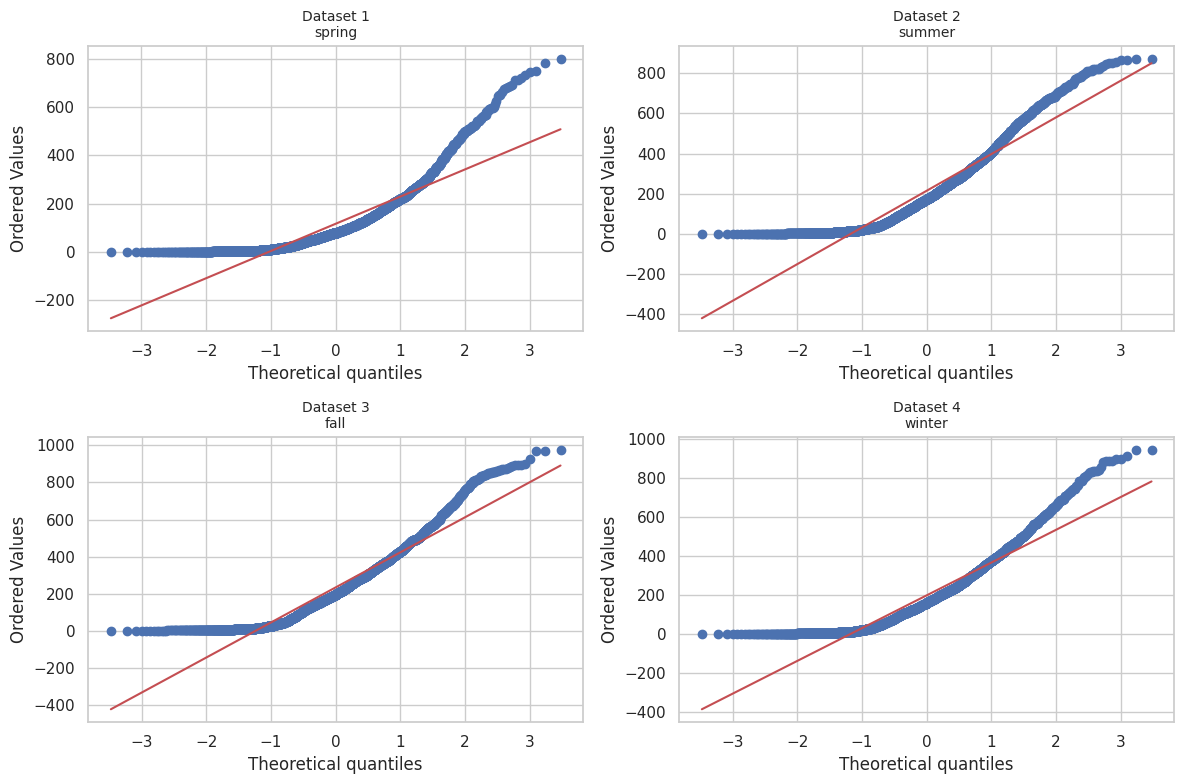

In [104]:
plot_qq(datasets, season)

####Skew and Kurt

In [105]:
spring.skew(), summer.skew(), fall.skew(), winter.skew()

(np.float64(1.8880559001782309),
 np.float64(1.0032642267278118),
 np.float64(0.9914946474772749),
 np.float64(1.172117329762622))

In [106]:
spring.kurtosis(), summer.kurtosis(), fall.kurtosis(), winter.kurtosis()

(np.float64(4.31475739331681),
 np.float64(0.42521337827415717),
 np.float64(0.6993825795653992),
 np.float64(1.2734853552995302))

####Shapiro-Wilks test

For Shapiro-Wilks test for normality

Ho : Gaussian or Normal Dist.

Ha : Not Normal Dist.

In [107]:
alpha=0.05

In [108]:
_, p = shapiro(spring)
check(p, alpha)

p =  8.749584618867662e-49
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [109]:
_, p = shapiro(summer)
check(p, alpha)

p =  6.039374406270491e-39
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [110]:
_, p = shapiro(fall)
check(p, alpha)

p =  1.043680518918597e-36
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [111]:
_, p = shapiro(winter)
check(p, alpha)

p =  1.1299244409282836e-39
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Variance Test

Ho : Variances are relatively equal across the groups

Ha : Variances significantly differ across the groups

In [112]:
levene_stat, p_value = levene(spring, summer, fall, winter)
print("Levene's statistic:", levene_stat)
print("p-value:", p_value)

Levene's statistic: 187.7706624026276
p-value: 1.0147116860043298e-118


In [113]:
check(p_value, alpha)

p =  1.0147116860043298e-118
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Hypothesis Testing

####F_oneway(ANOVA)

- Null hypothesis (H₀): The mean number of bicycles rented is the same across all seasons.

- Alternative hypothesis (H₁): At least one season has a different mean number of bicycles rented.

In [114]:
_, p = f_oneway(*datasets)
check(p, alpha)

p =  6.164843386499654e-149
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


####Kruskal

**Null Hypothesis (H0):**


  * In other words, there is no statistically significant difference in the medians of the groups being compared.

**Alternative Hypothesis (H1):**

  * There is a statistically significant difference in the medians of at least two groups.


In [115]:
_, p = kruskal(*datasets)
check(p, alpha)

p =  2.479008372608633e-151
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [116]:
df['season'].value_counts()

,count
season,
winter,2734
fall,2733
summer,2733
spring,2686


###Inference

Even though the counts are very close, the tests suggest that at least one season’s mean demand is different from the others.

###Business Recommendation:

>Although differences are small, operations should still monitor seasonal trends to ensure fleet availability and staffing are optimized.

>Slightly higher attention may be given to Winter, Summer and Fall, which have marginally higher rentals.

>Consider seasonal promotions or maintenance schedules to maintain efficiency and customer satisfaction.

>Continue tracking seasonal demand to detect shifts in trends and adjust operational strategies accordingly.

##Q-4
---
>Check if the Weather conditions are significantly different during different Seasons?
---

Ho : seasons and weather are independent OR not associated

Ha : seasons and weather are not independent OR associated

In [117]:
observed_data=pd.crosstab(df['season'], df['weather'], margins=True)

observed_data

weather,"Clear, Few clouds, partly cloudy, partly cloudy","Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog","Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds","Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist",All
season,,,,,
fall,1930,0,199,604,2733
spring,1759,1,211,715,2686
summer,1801,0,224,708,2733
winter,1702,0,225,807,2734
All,7192,1,859,2834,10886


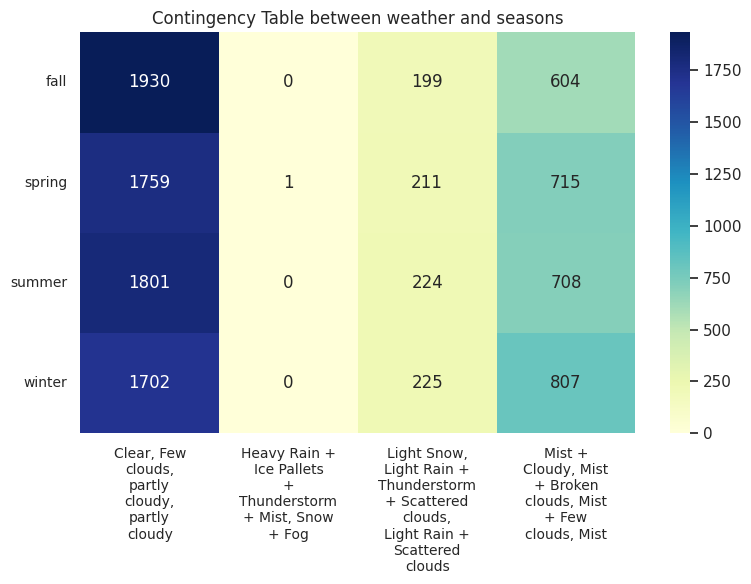

In [118]:
# Function to wrap long labels
def wrap_labels(labels, width=10):
    return ['\n'.join(textwrap.wrap(str(label), width)) for label in labels]

observed_data=pd.crosstab(df['season'], df['weather'])
# Wrap index (rows) and columns
observed_data.index = wrap_labels(observed_data.index, width=12)
observed_data.columns = wrap_labels(observed_data.columns, width=12)

# Plot heatmap
plt.figure(figsize=(8,6))
ax = sns.heatmap(observed_data, annot=True, fmt="d", cmap="YlGnBu")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)  # optional

plt.title("Contingency Table between weather and seasons", fontsize=12)
plt.tight_layout()
plt.show()

In [119]:
chi_stat, p_value, dof, expected_data = chi2_contingency(observed_data)
check(p_value, alpha)

p =  1.549925073686492e-07
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Inference
>Weather conditions are significantly associated with seasons. Some weather types are concentrated in specific seasons:

- Clear/Few clouds/Partly cloudy: high across all seasons.

- Light Snow/Light Rain/Thunderstorm: mostly in Winter, Summer, Spring, Fall.

- Heavy Rain / Ice / Snow + Fog: almost negligible, only in Spring.

- Mist/Cloudy: slightly higher in Winter and Spring.

###Business Recommendation

Operational Planning: Allocate bikes and staff based on seasonal weather patterns to optimize availability and reduce operational inefficiencies.

Forecast-Based Adjustments: Use weather forecasts to anticipate lower demand on adverse weather days (e.g., heavy snow or storms).

Promotions & Incentives: Offer special discounts or campaigns during low-demand weather periods to maintain rentals.

Data Monitoring: Continuously track weather vs rentals to refine seasonal demand forecasting and improve customer satisfaction.

##Q-5
---
>Temperature effect on rentals
---

Ho: Mean rentals are the same across temperature categories

Ha: At least one temperature category has different mean rentals

In [122]:
df['temp_level'],bins=pd.cut(df['temp'], bins=3, labels=['low', 'medium', 'high'], retbins=True)

In [123]:
bins

array([ 0.77982   , 14.21333333, 27.60666667, 41.        ])

In [124]:
df['temp_level'].value_counts()

,count
temp_level,
medium,5712
low,2926
high,2248


In [125]:
temp_low=df[df['temp_level']=='low']['count']
temp_medium=df[df['temp_level']=='medium']['count']
temp_high=df[df['temp_level']=='high']['count']

In [126]:
datasets = [temp_low, temp_medium, temp_high]

In [127]:
temps = {1: "low", 2: "medium", 3: "high"}

###Normality Test

####Histogram

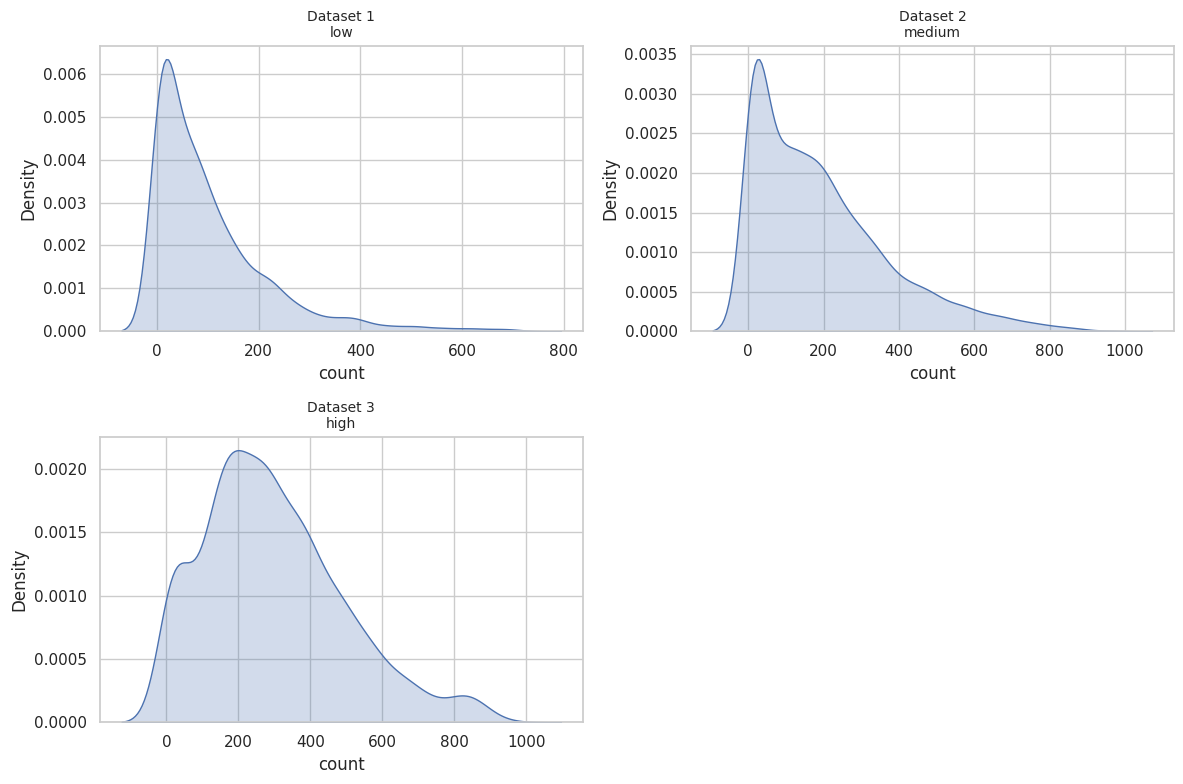

In [128]:
plot_kde(datasets, temps)

####Q-Q Plot

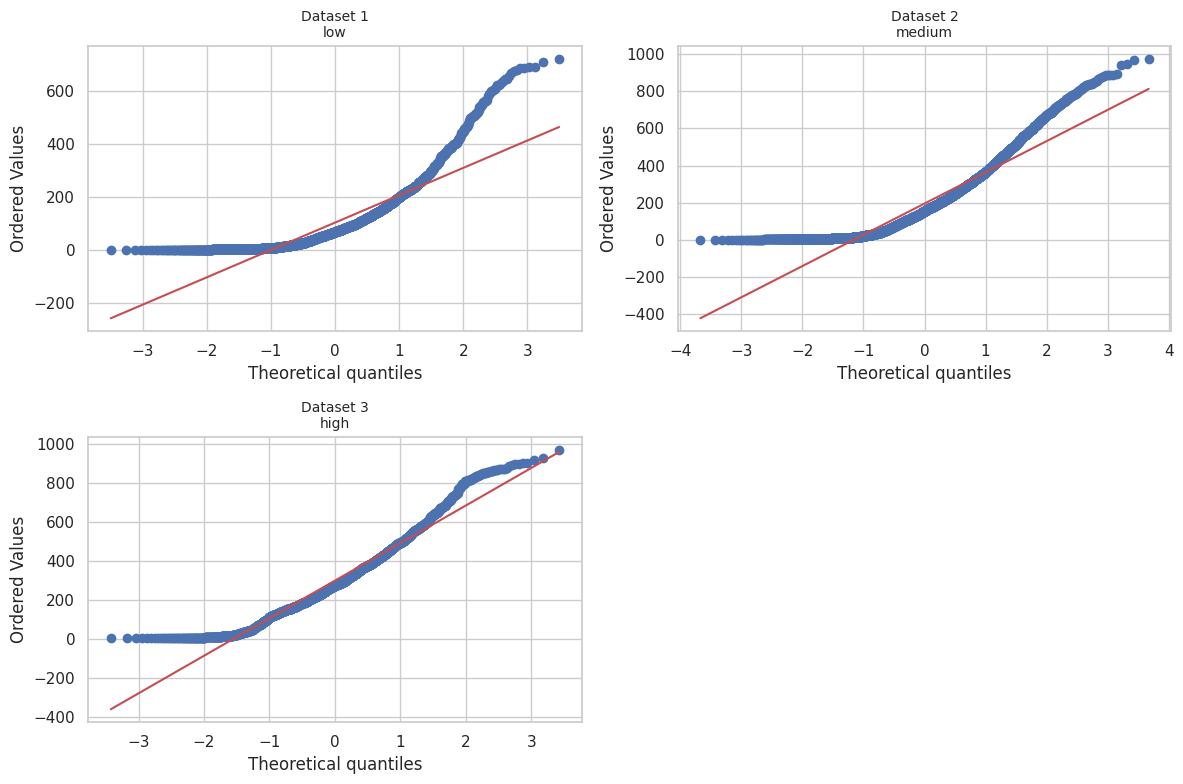

In [129]:
plot_qq(datasets, temps)

####Skew and Kurt

In [130]:
temp_low.skew(), temp_medium.skew(), temp_high.skew()

(np.float64(2.0015572621719353),
 np.float64(1.1994039745168597),
 np.float64(0.7190310052068541))

In [131]:
temp_low.kurtosis(), temp_medium.kurtosis(), temp_high.kurtosis()

(np.float64(4.9394326056415965),
 np.float64(1.216622050032619),
 np.float64(0.23736538767790183))

####Shapiro-Wilks test

For Shapiro-Wilks test for normality

Ho : Gaussian or Normal Dist.

Ha : Not Normal Dist.

In [132]:
alpha=0.05

In [133]:
_, p = shapiro(temp_low)
check(p, alpha)

p =  8.101775888779094e-52
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [134]:
_, p = shapiro(temp_medium)
check(p, alpha)

p =  9.6484025243229e-54
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5712.
  res = hypotest_fun_out(*samples, **kwds)


In [135]:
_, p = shapiro(temp_high)
check(p, alpha)

p =  3.2896290003660617e-25
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Variance Test

Ho : Variances are relatively equal across the groups

Ha : Variances significantly differ across the groups

In [136]:
levene_stat, p_value = levene(*datasets)
print("Levene's statistic:", levene_stat)
print("p-value:", p_value)

Levene's statistic: 334.5803924001447
p-value: 9.676707999897874e-142


In [137]:
check(p_value, alpha)

p =  9.676707999897874e-142
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


###Hypothesis Testing

####F_oneway(ANOVA)

- Null hypothesis (H₀): The mean number of bicycles rented is the same across all temp levels.

- Alternative hypothesis (H₁): At least one temp level has a different mean number of bicycles rented.

In [138]:
_, p = f_oneway(*datasets)
check(p, alpha)

p =  0.0
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


####Kruskal

**Null Hypothesis (H0):**


  * In other words, there is no statistically significant difference in the medians of the groups being compared.

**Alternative Hypothesis (H1):**

  * There is a statistically significant difference in the medians of at least two groups.


In [139]:
_, p = kruskal(*datasets)
check(p, alpha)

p =  0.0
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


####Peaesonr

In [140]:
corr, p = pearsonr(df['temp'], df['count'])
print("Correlation coefficient:", corr)

Correlation coefficient: 0.3944536449672491


###Inference
This indicates a moderate positive relationship, meaning higher temperatures are associated with more rentals. The result is statistically significant, suggesting temperature is an important factor affecting rental demand.

##Q-6
---
>Humidity effect on rentals
---

In [141]:
corr, p = pearsonr(df['humidity'], df['count'])
print("Correlation coefficient:", corr)


Correlation coefficient: -0.31737147887659456


###Inference

This means as humidity increases, the number of rentals tends to decrease.

##Q-7
---
>Are registered users affected by working day differently than casual users?
---

Ho: No difference in mean rentals for registered/casual users on working days vs non-working days

Ha: There is a difference

In [142]:
reg_working=df[df['workingday']=='yes']['registered']
reg_nonworking=df[df['workingday']=='no']['registered']
casual_working=df[df['workingday']=='yes']['casual']
casual_nonworking=df[df['workingday']=='no']['casual']

In [143]:
t_reg, p_reg = ttest_ind(reg_working, reg_nonworking, equal_var=False)
check(p_reg, alpha)

p =  2.905288442325148e-47
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


In [144]:
t_casual, p_casual = ttest_ind(casual_working, casual_nonworking, equal_var=False)
check(p_casual, alpha)

p =  1.8399668767689037e-145
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


##Q-8
---
>Do holidays affect total rentals?
---

Ho: Mean rentals on holidays = mean rentals on non-holidays

Ha: Mean rentals differ

In [145]:
holiday_count = df[df['holiday']=='yes']['count']
nonholiday_count = df[df['holiday']=='no']['count']

t_stat_hol, p_val_hol = ttest_ind(holiday_count, nonholiday_count, equal_var=False)

check(p_val_hol, alpha)


p =  0.5461309933605478
alpha =  0.05 

p > alpha

Fail to reject Ho



##Q-9
---
>Does the effect of working day on rentals depend on the season?
---

count : dependent var

season : independent var

workingday: independent var



- **Main Effect**

>Ho: independent var X has no effect on dependent var. i.e. all means as equal.

>Ha: independent var X affect the dependent. i.e. atleast one mean is different.

- **Interaction Effect**

>Ho: There is no interaction between independent vars.

>Ha: There is interaction between independent vars.

In [146]:

model = ols('count ~ C(season) + C(workingday) + C(season):C(workingday)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                               sum_sq       df           F         PR(>F)
C(season)                2.190057e+07      3.0  237.051664  5.339913e-149
C(workingday)            4.774407e+04      1.0    1.550345   2.131113e-01
C(season):C(workingday)  2.279540e+05      3.0    2.467373   6.018585e-02
Residual                 3.349964e+08  10878.0         NaN            NaN


In [147]:
2.131113e-01 > alpha,6.018585e-02 > alpha, 5.339913e-149 < alpha

(True, True, True)

###Inference

1. Main effect of Season (C(season))
    - reject Ho.
    - The mean number of rentals differs  significantly across seasons.
2. Main effect of Working Day (C(workingday))
    - fail to reject Ho
    - On its own, being a working day or not does not significantly affect rentals.
3. Interaction effect (C(season):C(workingday))
    - we fail to reject Ho
    - The effect of working day does not significantly depend on season, but it’s borderline—some seasons may slightly amplify working-day effects.



##Q-10
---
>Check if demand levels vary significantly across seasons.
---

Ho : No significant seasonal variation.

Ha: Demand distribution differs by season.

In [149]:
df['count_level'] = pd.qcut(df['count'], q=3, labels=['Low', 'Medium', 'High'])

In [150]:
ct1 = pd.crosstab(df['season'], df['count_level'])
chi2, p, dof, exp = chi2_contingency(ct1)

check(p, alpha)

p =  8.102110651794967e-143
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


>So demand distribution differ by season.

##Q-11
---
>
---

Ho: Weather doesn't significantly affects demand.

Ha: Weather significantly affects demand.

In [151]:
ct2 = pd.crosstab(df['weather'], df['count_level'])
chi2, p, dof, exp = chi2_contingency(ct2)

check(p, alpha)

p =  7.195777874079421e-42
alpha =  0.05 

p <= alpha

Ho - reject
Ha - accept


>Weather significantly affects demand.